In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [39]:
file_path = "/content/Kulakkada_Traffic data.xlsx"

# Load every worksheet
all_sheets = pd.read_excel(
    file_path,
    sheet_name=None
)

print("Worksheets found:")
for sheet_name in all_sheets.keys():
    print("-", sheet_name)

print("\nTotal worksheets:", len(all_sheets))

Worksheets found:
- Kulakkada_04-02-2025
- Kulakkada_05-02-2025
- Kulakkada_06-02-2025
- Kulakkada_07-02-2025

Total worksheets: 4


In [40]:
for sheet_name, sheet_df in all_sheets.items():

    print("\n" + "=" * 60)
    print(f"WORKSHEET: {sheet_name}")
    print("=" * 60)

    print("Rows:", len(sheet_df))
    print("Columns:", sheet_df.columns.tolist())

    display(sheet_df.head())


WORKSHEET: Kulakkada_04-02-2025
Rows: 8685
Columns: ['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']


,date,time,speed(kph),direction,heading,class_name,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2025-02-04,12:58:31,42.51,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-04,12:58:33,44.62,>,towardsAdoor,LCV 2 Axle Light Commercial Veh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-04,12:58:35,43.68,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN,6 hr data from 12.58 pm to 6.45pm,NaN
3,2025-02-04,12:58:36,46.35,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-02-04,12:58:37,35.74,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN,NaN,Row Labels,Count of class_name



WORKSHEET: Kulakkada_05-02-2025
Rows: 16455
Columns: ['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']


,date,time,speed(kph),direction,heading,class_name,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2025-02-05,09:49:16,40.98,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-05,09:49:16,61.66,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-05,09:49:18,64.91,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-02-05,09:49:17,64.95,<,towarkottarakkara,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN,10hr data from 9.45am to 8.00pm,NaN
4,2025-02-05,09:49:18,65.07,<,towarkottarakkara,3 Wheeler,NaN,NaN,NaN,NaN,NaN,NaN,NaN



WORKSHEET: Kulakkada_06-02-2025
Rows: 18026
Columns: ['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']


,date,time,speed(kph),direction,heading,class_name,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,2025-02-06,09:12:52,53.58,<,towarkottarakkara,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN
1,2025-02-06,09:12:53,43.79,>,towardsAdoor,LCV 2 Axle Light Commercial Veh,NaN,NaN,NaN,NaN,NaN
2,2025-02-06,09:12:56,36.79,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,11 hr data from 9.15 am to 8.00pm,NaN
3,2025-02-06,09:12:57,58.79,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN
4,2025-02-06,09:12:57,59.91,<,towarkottarakkara,MCV 2 Axle Rigid Truck or Bus,NaN,NaN,NaN,NaN,NaN



WORKSHEET: Kulakkada_07-02-2025
Rows: 14260
Columns: ['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']


,date,time,speed(kph),direction,heading,class_name,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,2025-02-07,09:16:22,22.70,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN
1,2025-02-07,09:16:30,47.41,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,10hr data from 9.15 am to 7.30 pm,NaN
2,2025-02-07,09:16:28,44.58,<,towarkottarakkara,MCV 2 Axle Rigid Truck or Bus,NaN,NaN,NaN,NaN
3,2025-02-07,09:16:30,45.32,<,towarkottarakkara,2 Wheeler,NaN,NaN,Row Labels,Count of class_name
4,2025-02-07,09:16:30,41.21,<,towarkottarakkara,2 Wheeler,NaN,NaN,2 Wheeler,4504


In [41]:
# Combine all worksheets into one DataFrame
df = pd.concat(
    all_sheets.values(),
    ignore_index=True
)

print("\n" + "=" * 60)
print("COMBINED DATASET")
print("=" * 60)

print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

display(df.head())


COMBINED DATASET
Total rows: 57426
Total columns: 13

Columns:
['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']


,date,time,speed(kph),direction,heading,class_name,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2025-02-04,12:58:31,42.51,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-04,12:58:33,44.62,>,towardsAdoor,LCV 2 Axle Light Commercial Veh,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-02-04,12:58:35,43.68,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN,6 hr data from 12.58 pm to 6.45pm,NaN
3,2025-02-04,12:58:36,46.35,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-02-04,12:58:37,35.74,<,towarkottarakkara,2 Wheeler,NaN,NaN,NaN,NaN,NaN,Row Labels,Count of class_name


In [42]:
print("\nRows contributed by each worksheet:")

for sheet_name, sheet_df in all_sheets.items():
    print(f"{sheet_name}: {len(sheet_df):,} rows")

print(f"\nCombined total: {len(df):,} rows")


Rows contributed by each worksheet:
Kulakkada_04-02-2025: 8,685 rows
Kulakkada_05-02-2025: 16,455 rows
Kulakkada_06-02-2025: 18,026 rows
Kulakkada_07-02-2025: 14,260 rows

Combined total: 57,426 rows


In [43]:
required_columns = [
    "date",
    "time",
    "speed(kph)",
    "direction",
    "heading",
    "class_name"
]

df_clean = df[required_columns].copy()

print("Columns retained:")
print(df_clean.columns.tolist())

print("\nRows before cleaning:", len(df_clean))

Columns retained:
['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name']

Rows before cleaning: 57426


In [44]:
# Convert date
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    errors="coerce"
)

# Convert time to string first
df_clean["time"] = df_clean["time"].astype(str).str.strip()

# Create timestamp
df_clean["timestamp"] = pd.to_datetime(
    df_clean["date"].dt.strftime("%Y-%m-%d") + " " + df_clean["time"],
    errors="coerce"
)

print("Invalid timestamps:",
      df_clean["timestamp"].isna().sum())

display(
    df_clean[
        ["date", "time", "timestamp"]
    ].head()
)

Invalid timestamps: 0


,date,time,timestamp
0,2025-02-04,12:58:31,2025-02-04 12:58:31
1,2025-02-04,12:58:33,2025-02-04 12:58:33
2,2025-02-04,12:58:35,2025-02-04 12:58:35
3,2025-02-04,12:58:36,2025-02-04 12:58:36
4,2025-02-04,12:58:37,2025-02-04 12:58:37


In [45]:
df_clean["speed(kph)"] = pd.to_numeric(
    df_clean["speed(kph)"],
    errors="coerce"
)

print(
    "Invalid speed values:",
    df_clean["speed(kph)"].isna().sum()
)

Invalid speed values: 0


In [46]:
# Remove records without a valid timestamp
df_clean = df_clean.dropna(
    subset=["timestamp"]
).copy()

# Remove records without a vehicle class
df_clean = df_clean.dropna(
    subset=["class_name"]
).copy()

# Convert class_name to string
df_clean["class_name"] = (
    df_clean["class_name"]
    .astype(str)
    .str.strip()
)

# Remove obvious embedded summary/header rows
invalid_class_patterns = [
    "count of class_name",
    "row labels"
]

mask_invalid = df_clean["class_name"].str.lower().isin(
    invalid_class_patterns
)

print(
    "Embedded summary/header rows detected:",
    mask_invalid.sum()
)

df_clean = df_clean[~mask_invalid].copy()

Embedded summary/header rows detected: 0


In [47]:
print("\n" + "=" * 60)
print("CLEANED DATASET")
print("=" * 60)

print("Rows after cleaning:", len(df_clean))
print("Columns:", df_clean.columns.tolist())

display(df_clean.head())


CLEANED DATASET
Rows after cleaning: 57426
Columns: ['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'timestamp']


,date,time,speed(kph),direction,heading,class_name,timestamp
0,2025-02-04,12:58:31,42.51,<,towarkottarakkara,2 Wheeler,2025-02-04 12:58:31
1,2025-02-04,12:58:33,44.62,>,towardsAdoor,LCV 2 Axle Light Commercial Veh,2025-02-04 12:58:33
2,2025-02-04,12:58:35,43.68,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,2025-02-04 12:58:35
3,2025-02-04,12:58:36,46.35,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,2025-02-04 12:58:36
4,2025-02-04,12:58:37,35.74,<,towarkottarakkara,2 Wheeler,2025-02-04 12:58:37


In [48]:
print("\nMissing values after cleaning:")

display(
    df_clean.isnull().sum()
)


Missing values after cleaning:


,0
date,0
time,0
speed(kph),0
direction,0
heading,0
class_name,0
timestamp,0


In [49]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 4


In [50]:
print("\nTime coverage:")

print("Start:",
      df_clean["timestamp"].min())

print("End:",
      df_clean["timestamp"].max())


Time coverage:
Start: 2025-02-04 12:58:31
End: 2025-02-07 17:33:22


In [51]:
records_by_date = (
    df_clean
    .groupby(df_clean["timestamp"].dt.date)
    .size()
    .reset_index(name="vehicle_records")
)

display(records_by_date)

,timestamp,vehicle_records
0,2025-02-04,8685
1,2025-02-05,16455
2,2025-02-06,18026
3,2025-02-07,14260


In [52]:
print("Unique vehicle classes:")

display(
    df_clean["class_name"]
    .value_counts()
    .to_frame("count")
)

Unique vehicle classes:


,count
class_name,
LMV 2 Axle Light Motor Vehicle,27823
2 Wheeler,18202
MCV 2 Axle Rigid Truck or Bus,3962
3 Wheeler,3490
LCV 2 Axle Light Commercial Veh,2278
SCV 2 Axle Small Commercial Veh,1076
HCV 3 Axle Rigid Truck or Bus,338
MAV 4 Axle Rigid Truck,167
Bicycle,34


In [53]:
print("\n" + "=" * 60)
print("FINAL BLOCK 4 VALIDATION")
print("=" * 60)

print("Total cleaned vehicle records:", len(df_clean))
print("Unique timestamps:", df_clean["timestamp"].nunique())
print("Missing timestamps:", df_clean["timestamp"].isna().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Unique vehicle classes:", df_clean["class_name"].nunique())


FINAL BLOCK 4 VALIDATION
Total cleaned vehicle records: 57426
Unique timestamps: 47782
Missing timestamps: 0
Duplicate rows: 4
Unique vehicle classes: 15


In [54]:
# INSPECT DUPLICATE RECORDS
duplicates = df_clean[
    df_clean.duplicated(keep=False)
].sort_values("timestamp")

print("Duplicate records found:", len(duplicates))

display(duplicates)

Duplicate records found: 8


,date,time,speed(kph),direction,heading,class_name,timestamp
8029,2025-02-04,18:24:26,44.37,<,towarkottarakkara,LMV 2 Axle Light Motor Vehicle,2025-02-04 18:24:26
8030,2025-02-04,18:24:26,44.37,<,towarkottarakkara,LMV 2 Axle Light Motor Vehicle,2025-02-04 18:24:26
24326,2025-02-05,19:29:10,60.07,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,2025-02-05 19:29:10
24327,2025-02-05,19:29:10,60.07,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,2025-02-05 19:29:10
32243,2025-02-06,13:20:13,58.08,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,2025-02-06 13:20:13
32244,2025-02-06,13:20:13,58.08,>,towardsAdoor,LMV 2 Axle Light Motor Vehicle,2025-02-06 13:20:13
44123,2025-02-07,09:26:46,43.05,>,towardsAdoor,2 Wheeler,2025-02-07 09:26:46
44125,2025-02-07,09:26:46,43.05,>,towardsAdoor,2 Wheeler,2025-02-07 09:26:46


In [55]:
# REMOVE EXACT DUPLICATE VEHICLE RECORDS
rows_before = len(df_clean)

# Remove exact duplicate records
df_clean = df_clean.drop_duplicates(
    subset=[
        "date",
        "time",
        "speed(kph)",
        "direction",
        "heading",
        "class_name"
    ],
    keep="first"
).copy()

rows_after = len(df_clean)

print("=" * 60)
print("DUPLICATE REMOVAL")
print("=" * 60)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

DUPLICATE REMOVAL
Rows before: 57426
Rows after: 57422
Duplicates removed: 4


In [56]:
# Final duplicate check
remaining_duplicates = df_clean.duplicated(
    subset=[
        "date",
        "time",
        "speed(kph)",
        "direction",
        "heading",
        "class_name"
    ]
).sum()

print("Remaining exact duplicates:", remaining_duplicates)

Remaining exact duplicates: 0


In [57]:
# HOURLY TRAFFIC VOLUME
# Make timestamp the index
df_hourly_base = df_clean.set_index("timestamp").copy()

# Count vehicles observed in each hour
hourly_traffic = (
    df_hourly_base
    .resample("1h")
    .size()
    .rename("vehicle_count")
    .to_frame()
)

print("=" * 60)
print("HOURLY TRAFFIC VOLUME")
print("=" * 60)

print("Number of hourly periods:", len(hourly_traffic))

display(hourly_traffic.head(20))

HOURLY TRAFFIC VOLUME
Number of hourly periods: 78


,vehicle_count
timestamp,
2025-02-04 12:00:00,42
2025-02-04 13:00:00,1291
2025-02-04 14:00:00,1216
2025-02-04 15:00:00,1456
2025-02-04 16:00:00,1543
2025-02-04 17:00:00,1746
2025-02-04 18:00:00,1390
2025-02-04 19:00:00,0
2025-02-04 20:00:00,0


In [58]:
# IDENTIFY OBSERVATION GAPS
hourly_traffic["data_available"] = (
    hourly_traffic["vehicle_count"] > 0
)

print("Total hourly timestamps created:", len(hourly_traffic))

print(
    "Hours with recorded vehicles:",
    hourly_traffic["data_available"].sum()
)

print(
    "Hours with no recorded observations:",
    (~hourly_traffic["data_available"]).sum()
)

display(
    hourly_traffic[
        hourly_traffic["vehicle_count"] == 0
    ].head(30)
)

Total hourly timestamps created: 78
Hours with recorded vehicles: 41
Hours with no recorded observations: 37


,vehicle_count,data_available
timestamp,,
2025-02-04 19:00:00,0,False
2025-02-04 20:00:00,0,False
2025-02-04 21:00:00,0,False
2025-02-04 22:00:00,0,False
2025-02-04 23:00:00,0,False
2025-02-05 00:00:00,0,False
2025-02-05 01:00:00,0,False
2025-02-05 02:00:00,0,False
2025-02-05 03:00:00,0,False


In [59]:
# OBSERVED HOURLY TRAFFIC SERIES
# Keep only hours where actual vehicle records exist
observed_hourly = hourly_traffic[
    hourly_traffic["data_available"] == True
].copy()

# Remove the helper column
observed_hourly = observed_hourly.drop(
    columns=["data_available"]
)

print("=" * 60)
print("OBSERVED HOURLY TRAFFIC SERIES")
print("=" * 60)

print("Observed hourly periods:", len(observed_hourly))

print("\nStart:",
      observed_hourly.index.min())

print("End:",
      observed_hourly.index.max())

display(observed_hourly)

OBSERVED HOURLY TRAFFIC SERIES
Observed hourly periods: 41

Start: 2025-02-04 12:00:00
End: 2025-02-07 17:00:00


,vehicle_count
timestamp,
2025-02-04 12:00:00,42
2025-02-04 13:00:00,1291
2025-02-04 14:00:00,1216
2025-02-04 15:00:00,1456
2025-02-04 16:00:00,1543
2025-02-04 17:00:00,1746
2025-02-04 18:00:00,1390
2025-02-05 09:00:00,790
2025-02-05 10:00:00,1621


In [60]:
# OBSERVATIONS BY DATE
observed_hourly["date"] = observed_hourly.index.date

daily_hourly_summary = (
    observed_hourly
    .groupby("date")
    .agg(
        observed_hours=("vehicle_count", "count"),
        total_vehicles=("vehicle_count", "sum"),
        peak_hourly_traffic=("vehicle_count", "max"),
        average_hourly_traffic=("vehicle_count", "mean")
    )
)

print("=" * 60)
print("DAILY HOURLY TRAFFIC SUMMARY")
print("=" * 60)

display(daily_hourly_summary)

DAILY HOURLY TRAFFIC SUMMARY


,observed_hours,total_vehicles,peak_hourly_traffic,average_hourly_traffic
date,,,,
2025-02-04,7,8684,1746,1240.571429
2025-02-05,12,16454,1872,1371.166667
2025-02-06,12,18025,2047,1502.083333
2025-02-07,10,14259,1981,1425.900000


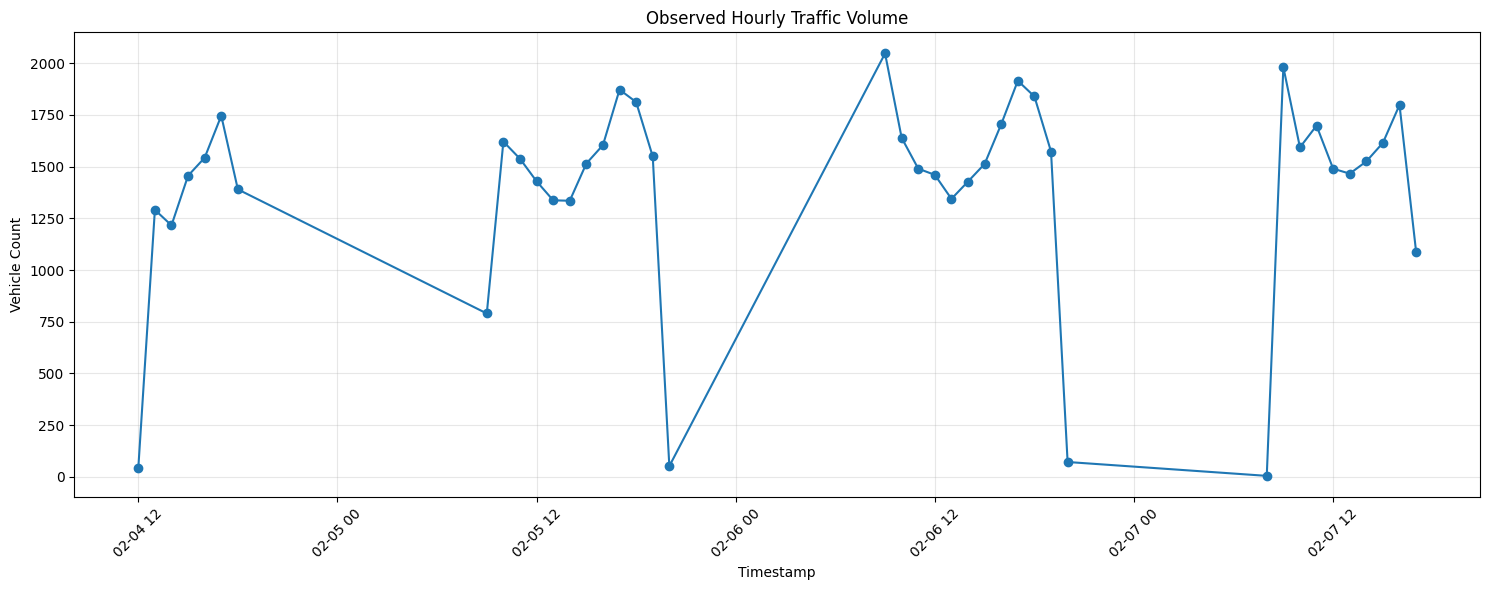

In [61]:
# OBSERVED HOURLY TRAFFIC VISUALIZATION
plt.figure(figsize=(15, 6))

plt.plot(
    observed_hourly.index,
    observed_hourly["vehicle_count"],
    marker="o"
)

plt.title("Observed Hourly Traffic Volume")
plt.xlabel("Timestamp")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
# DESCRIPTIVE STATISTICS
traffic_stats = observed_hourly["vehicle_count"].describe()

print("=" * 60)
print("DESCRIPTIVE STATISTICS — HOURLY TRAFFIC")
print("=" * 60)

display(traffic_stats.to_frame("vehicle_count"))

DESCRIPTIVE STATISTICS — HOURLY TRAFFIC


,vehicle_count
count,41.000000
mean,1400.536585
std,508.853618
min,5.000000
25%,1344.000000
50%,1515.000000
75%,1639.000000
max,2047.000000


In [63]:
# KEY TRAFFIC METRICS
mean_traffic = observed_hourly["vehicle_count"].mean()
median_traffic = observed_hourly["vehicle_count"].median()
std_traffic = observed_hourly["vehicle_count"].std()
min_traffic = observed_hourly["vehicle_count"].min()
max_traffic = observed_hourly["vehicle_count"].max()

peak_timestamp = observed_hourly[
    "vehicle_count"
].idxmax()

lowest_timestamp = observed_hourly[
    "vehicle_count"
].idxmin()

print("=" * 60)
print("KEY TRAFFIC METRICS")
print("=" * 60)

print(f"Mean hourly traffic      : {mean_traffic:.2f}")
print(f"Median hourly traffic    : {median_traffic:.2f}")
print(f"Standard deviation       : {std_traffic:.2f}")
print(f"Minimum hourly traffic   : {min_traffic}")
print(f"Maximum hourly traffic   : {max_traffic}")

print(f"\nPeak traffic timestamp   : {peak_timestamp}")
print(f"Peak traffic volume      : {max_traffic}")

print(f"\nLowest traffic timestamp : {lowest_timestamp}")
print(f"Lowest traffic volume    : {min_traffic}")

KEY TRAFFIC METRICS
Mean hourly traffic      : 1400.54
Median hourly traffic    : 1515.00
Standard deviation       : 508.85
Minimum hourly traffic   : 5
Maximum hourly traffic   : 2047

Peak traffic timestamp   : 2025-02-06 09:00:00
Peak traffic volume      : 2047

Lowest traffic timestamp : 2025-02-07 08:00:00
Lowest traffic volume    : 5


In [64]:
# TRAFFIC BY HOUR OF DAY
observed_hourly["hour"] = observed_hourly.index.hour

hourly_pattern = (
    observed_hourly
    .groupby("hour")["vehicle_count"]
    .agg(
        observations="count",
        average_traffic="mean",
        total_traffic="sum",
        maximum_traffic="max"
    )
    .reset_index()
)

print("=" * 60)
print("TRAFFIC PATTERN BY HOUR OF DAY")
print("=" * 60)

display(hourly_pattern)

TRAFFIC PATTERN BY HOUR OF DAY


,hour,observations,average_traffic,total_traffic,maximum_traffic
0,8,1,5.000000,5,5
1,9,3,1606.000000,4818,2047
2,10,3,1617.666667,4853,1639
3,11,3,1575.333333,4726,1698
4,12,4,1105.250000,4421,1490
5,13,4,1359.500000,5438,1466
6,14,4,1376.000000,5504,1525
7,15,4,1524.750000,6099,1615
8,16,4,1662.500000,6650,1798
9,17,4,1655.250000,6621,1915


In [65]:
# BUSIEST HOUR
busiest_hour = hourly_pattern.loc[
    hourly_pattern["average_traffic"].idxmax()
]

print("Busiest observed hour:")
print(
    f"{int(busiest_hour['hour']):02d}:00 "
    f"→ average traffic = "
    f"{busiest_hour['average_traffic']:.2f} vehicles"
)

Busiest observed hour:
18:00 → average traffic = 1680.33 vehicles


In [66]:
# DIRECTION-WISE TRAFFIC
direction_summary = (
    df_clean
    .groupby("direction")
    .size()
    .reset_index(name="vehicle_count")
    .sort_values(
        "vehicle_count",
        ascending=False
    )
)

print("=" * 60)
print("DIRECTION-WISE TRAFFIC")
print("=" * 60)

display(direction_summary)

DIRECTION-WISE TRAFFIC


,direction,vehicle_count
0,<,29024
1,>,28398


In [67]:
# DIRECTION SHARE
direction_summary["percentage"] = (
    direction_summary["vehicle_count"]
    / direction_summary["vehicle_count"].sum()
    * 100
)

display(direction_summary)

,direction,vehicle_count,percentage
0,<,29024,50.545087
1,>,28398,49.454913


In [68]:
# VEHICLE CLASS DISTRIBUTION
vehicle_class_summary = (
    df_clean
    .groupby("class_name")
    .size()
    .reset_index(name="vehicle_count")
    .sort_values(
        "vehicle_count",
        ascending=False
    )
)

vehicle_class_summary["percentage"] = (
    vehicle_class_summary["vehicle_count"]
    / vehicle_class_summary["vehicle_count"].sum()
    * 100
)

print("=" * 60)
print("VEHICLE CLASS DISTRIBUTION")
print("=" * 60)

display(vehicle_class_summary)

VEHICLE CLASS DISTRIBUTION


,class_name,vehicle_count,percentage
5,LMV 2 Axle Light Motor Vehicle,27820,48.448330
0,2 Wheeler,18201,31.696911
11,MCV 2 Axle Rigid Truck or Bus,3962,6.899795
1,3 Wheeler,3490,6.077810
4,LCV 2 Axle Light Commercial Veh,2278,3.967121
12,SCV 2 Axle Small Commercial Veh,1076,1.873846
3,HCV 3 Axle Rigid Truck or Bus,338,0.588625
7,MAV 4 Axle Rigid Truck,167,0.290829
2,Bicycle,34,0.059211
6,MAV 4 Axle Articulated Truck,17,0.029605


In [69]:
# DAILY TRAFFIC VOLUME
daily_traffic = (
    df_clean
    .groupby(
        df_clean["timestamp"].dt.date
    )
    .size()
    .reset_index(name="vehicle_count")
)

daily_traffic.columns = [
    "date",
    "vehicle_count"
]

print("=" * 60)
print("DAILY TRAFFIC VOLUME")
print("=" * 60)

display(daily_traffic)

DAILY TRAFFIC VOLUME


,date,vehicle_count
0,2025-02-04,8684
1,2025-02-05,16454
2,2025-02-06,18025
3,2025-02-07,14259


In [70]:
# DAILY TRAFFIC SHARE
daily_traffic["percentage"] = (
    daily_traffic["vehicle_count"]
    / daily_traffic["vehicle_count"].sum()
    * 100
)

display(daily_traffic)

,date,vehicle_count,percentage
0,2025-02-04,8684,15.123124
1,2025-02-05,16454,28.654523
2,2025-02-06,18025,31.390408
3,2025-02-07,14259,24.831946


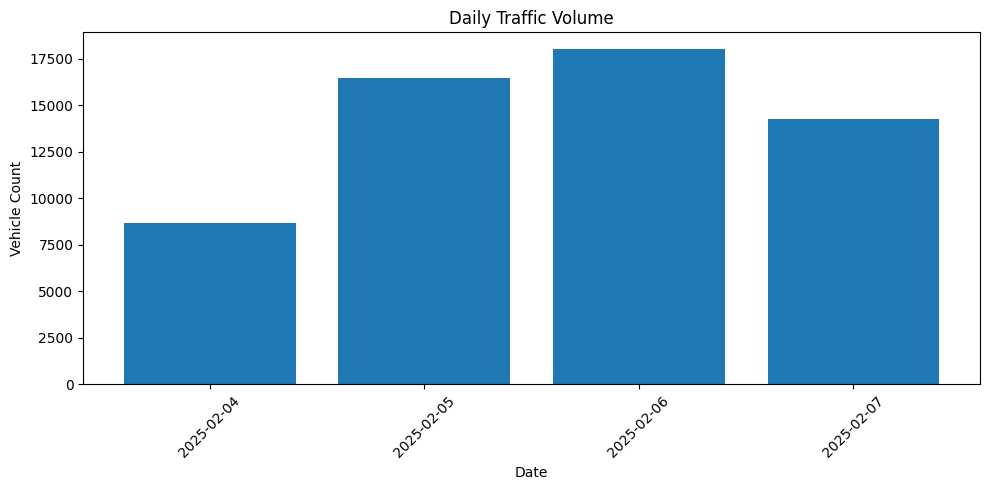

In [71]:
# DAILY TRAFFIC CHART
plt.figure(figsize=(10, 5))

plt.bar(
    daily_traffic["date"].astype(str),
    daily_traffic["vehicle_count"]
)

plt.title("Daily Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Vehicle Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

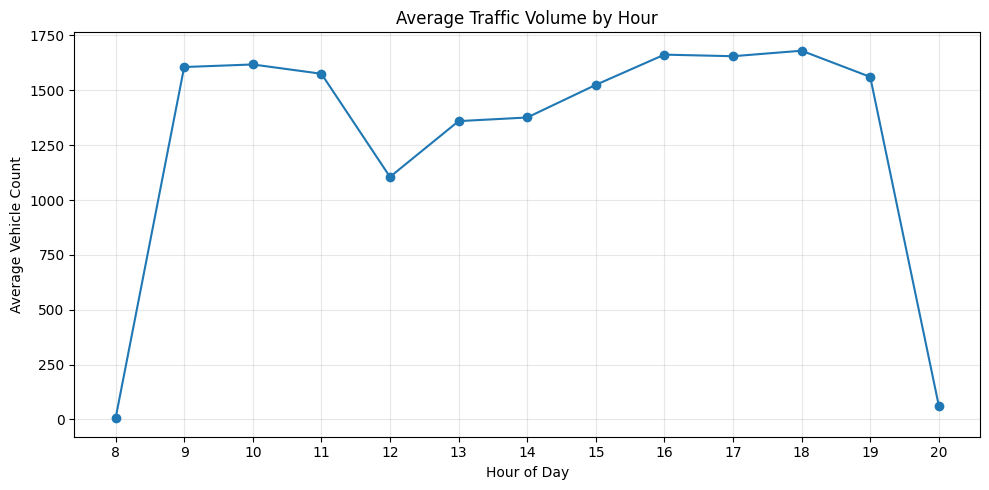

In [72]:
# HOURLY TRAFFIC PATTERN
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_pattern["hour"],
    hourly_pattern["average_traffic"],
    marker="o"
)

plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")

plt.xticks(
    hourly_pattern["hour"]
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

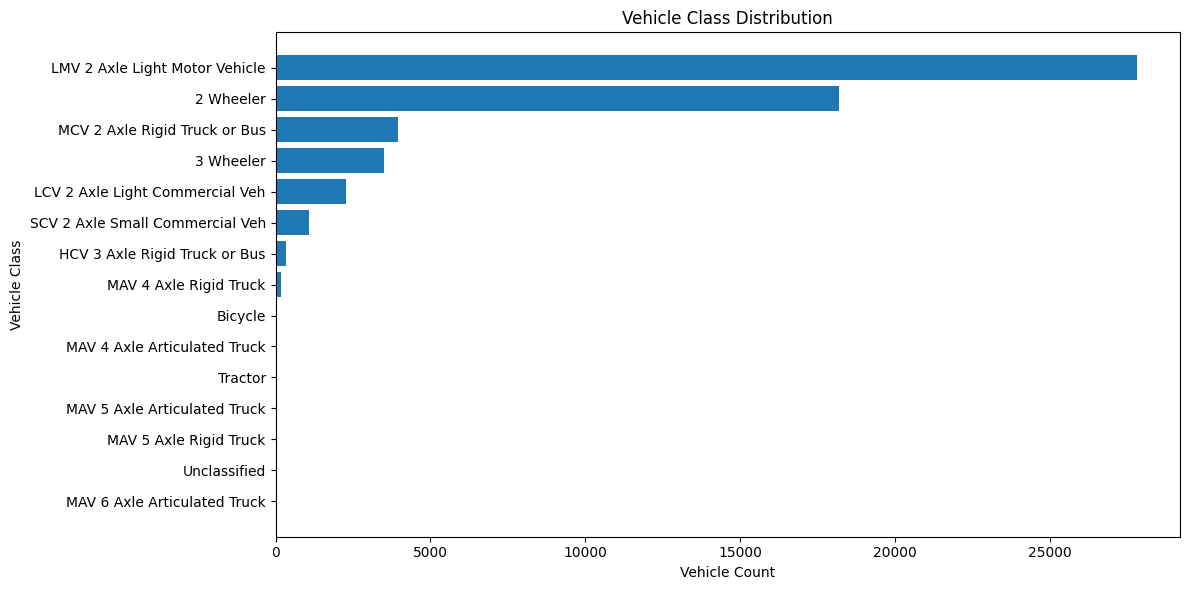

In [73]:
# VEHICLE CLASS DISTRIBUTION
plt.figure(figsize=(12, 6))

plt.barh(
    vehicle_class_summary["class_name"],
    vehicle_class_summary["vehicle_count"]
)

plt.title("Vehicle Class Distribution")
plt.xlabel("Vehicle Count")
plt.ylabel("Vehicle Class")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [79]:
import pandas as pd

print("DataFrames currently available:")

dataframes = [
    (name, obj)
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame)
]

for name, obj in dataframes:
    print(f"{name}: {obj.shape}")

DataFrames currently available:
sheet_df: (14260, 10)
df: (57426, 13)
df_clean: (57422, 7)
records_by_date: (4, 2)
duplicates: (8, 7)
df_hourly_base: (57422, 6)
hourly_traffic: (78, 2)
observed_hourly: (41, 3)
daily_hourly_summary: (4, 4)
hourly_pattern: (13, 5)
direction_summary: (2, 3)
vehicle_class_summary: (15, 3)
daily_traffic: (4, 3)
speed_data: (57426, 13)


In [80]:
# ============================================================
# BLOCK 7 — SPEED ANALYSIS
# ============================================================

print("=" * 60)
print("SPEED ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. USE EXISTING SPEED DATA
# ------------------------------------------------------------

speed_data = speed_data.copy()

print(f"\nSpeed dataframe shape: {speed_data.shape}")

print("\nAvailable columns:")
print(list(speed_data.columns))


# ------------------------------------------------------------
# 2. SPEED DATA VALIDATION
# ------------------------------------------------------------

# Ensure speed is numeric
speed_data["speed(kph)"] = pd.to_numeric(
    speed_data["speed(kph)"],
    errors="coerce"
)

valid_speed = speed_data["speed(kph)"].notna()

print("\n" + "=" * 60)
print("SPEED DATA VALIDATION")
print("=" * 60)

print(f"Total records with valid speed: {valid_speed.sum()}")
print(f"Missing speed values          : {speed_data['speed(kph)'].isna().sum()}")

print("\nSpeed range:")

print(
    f"Minimum speed: "
    f"{speed_data.loc[valid_speed, 'speed(kph)'].min():.2f} km/h"
)

print(
    f"Maximum speed: "
    f"{speed_data.loc[valid_speed, 'speed(kph)'].max():.2f} km/h"
)


# ------------------------------------------------------------
# 3. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

speed_stats = (
    speed_data.loc[valid_speed, "speed(kph)"]
    .describe()
)

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS — VEHICLE SPEED")
print("=" * 60)

display(
    speed_stats.to_frame(name="speed_kph")
)

print("\nKey speed metrics:")

print(
    f"Mean speed        : "
    f"{speed_stats['mean']:.2f} km/h"
)

print(
    f"Median speed      : "
    f"{speed_stats['50%']:.2f} km/h"
)

print(
    f"Standard deviation: "
    f"{speed_stats['std']:.2f} km/h"
)

print(
    f"Minimum speed     : "
    f"{speed_stats['min']:.2f} km/h"
)

print(
    f"Maximum speed     : "
    f"{speed_stats['max']:.2f} km/h"
)


# ------------------------------------------------------------
# 4. CHECK TIMESTAMP COLUMN
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TIMESTAMP VALIDATION")
print("=" * 60)

if "timestamp" in speed_data.columns:

    print("Timestamp column found.")

    speed_data["timestamp"] = pd.to_datetime(
        speed_data["timestamp"],
        errors="coerce"
    )

else:

    print("Timestamp column NOT found.")

    # Try to construct timestamp from date and time
    if "date" in speed_data.columns and "time" in speed_data.columns:

        speed_data["timestamp"] = pd.to_datetime(
            speed_data["date"].astype(str)
            + " "
            + speed_data["time"].astype(str),
            errors="coerce"
        )

        print("Timestamp successfully created from date + time.")

    else:

        speed_data["timestamp"] = pd.NaT

        print(
            "WARNING: Date/time columns are also unavailable. "
            "Timestamp cannot be reconstructed."
        )


# ------------------------------------------------------------
# 5. EXTREME SPEED OBSERVATIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EXTREME SPEED OBSERVATIONS")
print("=" * 60)


# Highest speed
max_idx = speed_data.loc[valid_speed, "speed(kph)"].idxmax()
max_speed_row = speed_data.loc[max_idx]

print("\nHighest recorded speed:")

print(
    f"Speed     : "
    f"{max_speed_row['speed(kph)']:.2f} km/h"
)

if pd.notna(max_speed_row["timestamp"]):
    print(
        f"Timestamp : "
        f"{max_speed_row['timestamp']}"
    )
else:
    print("Timestamp : Not available")


if "direction" in speed_data.columns:
    print(
        f"Direction : "
        f"{max_speed_row['direction']}"
    )

if "class_name" in speed_data.columns:
    print(
        f"Class     : "
        f"{max_speed_row['class_name']}"
    )


# Lowest speed
min_idx = speed_data.loc[valid_speed, "speed(kph)"].idxmin()
min_speed_row = speed_data.loc[min_idx]

print("\nLowest recorded speed:")

print(
    f"Speed     : "
    f"{min_speed_row['speed(kph)']:.2f} km/h"
)

if pd.notna(min_speed_row["timestamp"]):
    print(
        f"Timestamp : "
        f"{min_speed_row['timestamp']}"
    )
else:
    print("Timestamp : Not available")


if "direction" in speed_data.columns:
    print(
        f"Direction : "
        f"{min_speed_row['direction']}"
    )

if "class_name" in speed_data.columns:
    print(
        f"Class     : "
        f"{min_speed_row['class_name']}"
    )


# ------------------------------------------------------------
# 6. SPEED DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPEED DISTRIBUTION")
print("=" * 60)

speed_bins = [
    0,
    20,
    40,
    60,
    80,
    100,
    120,
    float("inf")
]

speed_labels = [
    "0–20",
    "20–40",
    "40–60",
    "60–80",
    "80–100",
    "100–120",
    "120+"
]

speed_data["speed_range"] = pd.cut(
    speed_data["speed(kph)"],
    bins=speed_bins,
    labels=speed_labels,
    right=False
)

speed_distribution = (
    speed_data.loc[valid_speed]
    .groupby(
        "speed_range",
        observed=False
    )
    .size()
    .reset_index(name="vehicle_count")
)

speed_distribution["percentage"] = (
    speed_distribution["vehicle_count"]
    / speed_distribution["vehicle_count"].sum()
    * 100
)

display(speed_distribution)


# ------------------------------------------------------------
# 7. AVERAGE SPEED BY VEHICLE CLASS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AVERAGE SPEED BY VEHICLE CLASS")
print("=" * 60)

speed_by_class = (
    speed_data.loc[valid_speed]
    .groupby("class_name")["speed(kph)"]
    .agg(
        vehicle_count="count",
        average_speed="mean",
        median_speed="median",
        maximum_speed="max"
    )
    .sort_values(
        "average_speed",
        ascending=False
    )
)

display(speed_by_class)


# ------------------------------------------------------------
# 8. SPEED BY DIRECTION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPEED BY DIRECTION")
print("=" * 60)

speed_by_direction = (
    speed_data.loc[valid_speed]
    .groupby("direction")["speed(kph)"]
    .agg(
        vehicle_count="count",
        average_speed="mean",
        median_speed="median",
        maximum_speed="max"
    )
    .reset_index()
)

display(speed_by_direction)


# ------------------------------------------------------------
# 9. HIGH-SPEED OBSERVATIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HIGH-SPEED OBSERVATIONS")
print("=" * 60)

high_speed_threshold = 80

high_speed_data = speed_data[
    speed_data["speed(kph)"] >= high_speed_threshold
].copy()

high_speed_count = len(high_speed_data)

high_speed_percentage = (
    high_speed_count
    / valid_speed.sum()
    * 100
)

print(
    f"High-speed threshold: ≥ {high_speed_threshold} km/h"
)

print(
    f"High-speed records  : {high_speed_count}"
)

print(
    f"Percentage          : {high_speed_percentage:.2f}%"
)

if high_speed_count > 0:

    columns_to_display = []

    for column in [
        "timestamp",
        "speed(kph)",
        "direction",
        "class_name"
    ]:

        if column in high_speed_data.columns:
            columns_to_display.append(column)

    display(
        high_speed_data[
            columns_to_display
        ]
        .sort_values(
            "speed(kph)",
            ascending=False
        )
        .head(20)
    )


# ------------------------------------------------------------
# 10. FINAL BLOCK 7 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 7 — FINAL SUMMARY")
print("=" * 60)

print(
    f"Total vehicle records : "
    f"{len(speed_data):,}"
)

print(
    f"Valid speed records   : "
    f"{valid_speed.sum():,}"
)

print(
    f"Missing speed records : "
    f"{speed_data['speed(kph)'].isna().sum():,}"
)

print(
    f"Mean speed            : "
    f"{speed_data.loc[valid_speed, 'speed(kph)'].mean():.2f} km/h"
)

print(
    f"Median speed          : "
    f"{speed_data.loc[valid_speed, 'speed(kph)'].median():.2f} km/h"
)

print(
    f"Maximum speed         : "
    f"{speed_data.loc[valid_speed, 'speed(kph)'].max():.2f} km/h"
)

print(
    f"Minimum speed         : "
    f"{speed_data.loc[valid_speed, 'speed(kph)'].min():.2f} km/h"
)

print(
    f"High-speed records    : "
    f"{high_speed_count:,}"
)

print(
    f"High-speed percentage : "
    f"{high_speed_percentage:.2f}%"
)

print("\n" + "=" * 60)
print("BLOCK 7 COMPLETED")
print("=" * 60)

SPEED ANALYSIS

Speed dataframe shape: (57426, 13)

Available columns:
['date', 'time', 'speed(kph)', 'direction', 'heading', 'class_name', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']

SPEED DATA VALIDATION
Total records with valid speed: 57426
Missing speed values          : 0

Speed range:
Minimum speed: 1.64 km/h
Maximum speed: 176.32 km/h

DESCRIPTIVE STATISTICS — VEHICLE SPEED


,speed_kph
count,57426.000000
mean,48.787661
std,11.076607
min,1.640000
25%,41.580000
50%,48.720000
75%,56.030000
max,176.320000



Key speed metrics:
Mean speed        : 48.79 km/h
Median speed      : 48.72 km/h
Standard deviation: 11.08 km/h
Minimum speed     : 1.64 km/h
Maximum speed     : 176.32 km/h

TIMESTAMP VALIDATION
Timestamp column NOT found.
Timestamp successfully created from date + time.

EXTREME SPEED OBSERVATIONS

Highest recorded speed:
Speed     : 176.32 km/h
Timestamp : 2025-02-07 14:56:27
Direction : <
Class     : Bicycle

Lowest recorded speed:
Speed     : 1.64 km/h
Timestamp : 2025-02-06 14:58:07
Direction : <
Class     : 2 Wheeler

SPEED DISTRIBUTION


,speed_range,vehicle_count,percentage
0,0–20,507,0.882875
1,20–40,11087,19.306586
2,40–60,37219,64.812106
3,60–80,8423,14.667572
4,80–100,183,0.318671
5,100–120,5,0.008707
6,120+,2,0.003483



AVERAGE SPEED BY VEHICLE CLASS


...


SPEED BY DIRECTION


,direction,vehicle_count,average_speed,median_speed,maximum_speed
0,<,29025,47.897185,47.66,176.32
1,>,28401,49.697701,49.71,121.84



HIGH-SPEED OBSERVATIONS
High-speed threshold: ≥ 80 km/h
High-speed records  : 190
Percentage          : 0.33%


,timestamp,speed(kph),direction,class_name
52827,2025-02-07 14:56:27,176.32,<,Bicycle
34387,2025-02-06 14:53:29,121.84,>,2 Wheeler
15124,2025-02-05 13:47:24,112.04,>,LMV 2 Axle Light Motor Vehicle
11358,2025-02-05 11:10:11,110.36,>,LCV 2 Axle Light Commercial Veh
14818,2025-02-05 13:34:05,109.28,>,2 Wheeler
4616,2025-02-04 16:23:58,104.50,<,2 Wheeler
13649,2025-02-05 12:41:43,102.54,<,2 Wheeler
20807,2025-02-05 17:31:45,99.74,<,2 Wheeler
16563,2025-02-05 14:52:05,99.21,<,LMV 2 Axle Light Motor Vehicle
57136,2025-02-07 17:25:06,97.68,<,2 Wheeler



BLOCK 7 — FINAL SUMMARY
Total vehicle records : 57,426
Valid speed records   : 57,426
Missing speed records : 0
Mean speed            : 48.79 km/h
Median speed          : 48.72 km/h
Maximum speed         : 176.32 km/h
Minimum speed         : 1.64 km/h
High-speed records    : 190
High-speed percentage : 0.33%

BLOCK 7 COMPLETED


In [81]:
# ============================================================
# BLOCK 8 — SPEED/TIME & SPEED/CLASS ANALYSIS
# ============================================================

print("=" * 60)
print("BLOCK 8 — SPEED/TIME & SPEED/CLASS ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

# Use the cleaned vehicle-level dataframe
speed_analysis = df_clean.copy()

# Make sure speed is numeric
speed_analysis["speed(kph)"] = pd.to_numeric(
    speed_analysis["speed(kph)"],
    errors="coerce"
)

# Remove rows where speed is missing
speed_analysis = speed_analysis.dropna(subset=["speed(kph)"]).copy()

# Create timestamp only if date/time columns are available
if "timestamp" in speed_analysis.columns:
    speed_analysis["timestamp"] = pd.to_datetime(
        speed_analysis["timestamp"],
        errors="coerce"
    )

elif "date" in speed_analysis.columns and "time" in speed_analysis.columns:
    speed_analysis["timestamp"] = pd.to_datetime(
        speed_analysis["date"].astype(str) + " " +
        speed_analysis["time"].astype(str),
        errors="coerce"
    )

elif "datetime" in speed_analysis.columns:
    speed_analysis["timestamp"] = pd.to_datetime(
        speed_analysis["datetime"],
        errors="coerce"
    )

else:
    print("\nWARNING: No timestamp/date-time column found.")
    print("Available columns:")
    print(list(speed_analysis.columns))


# ------------------------------------------------------------
# 2. SPEED BY HOUR OF DAY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPEED BY HOUR OF DAY")
print("=" * 60)

if "timestamp" in speed_analysis.columns:

    speed_analysis["hour"] = speed_analysis["timestamp"].dt.hour

    speed_by_hour = (
        speed_analysis
        .groupby("hour")["speed(kph)"]
        .agg(
            observations="count",
            average_speed="mean",
            median_speed="median",
            minimum_speed="min",
            maximum_speed="max"
        )
        .reset_index()
    )

    speed_by_hour["average_speed"] = speed_by_hour["average_speed"].round(2)
    speed_by_hour["median_speed"] = speed_by_hour["median_speed"].round(2)
    speed_by_hour["minimum_speed"] = speed_by_hour["minimum_speed"].round(2)
    speed_by_hour["maximum_speed"] = speed_by_hour["maximum_speed"].round(2)

    print(speed_by_hour.to_string(index=False))

else:
    speed_by_hour = None


# ------------------------------------------------------------
# 3. PEAK SPEED PERIODS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PEAK SPEED PERIODS")
print("=" * 60)

if speed_by_hour is not None:

    busiest_speed_hour = speed_by_hour.loc[
        speed_by_hour["average_speed"].idxmax()
    ]

    lowest_speed_hour = speed_by_hour.loc[
        speed_by_hour["average_speed"].idxmin()
    ]

    print(
        f"Highest average speed hour : "
        f"{int(busiest_speed_hour['hour']):02d}:00 "
        f"→ {busiest_speed_hour['average_speed']:.2f} km/h"
    )

    print(
        f"Lowest average speed hour  : "
        f"{int(lowest_speed_hour['hour']):02d}:00 "
        f"→ {lowest_speed_hour['average_speed']:.2f} km/h"
    )


# ------------------------------------------------------------
# 4. SPEED BY VEHICLE CLASS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPEED BY VEHICLE CLASS")
print("=" * 60)

if "class_name" in speed_analysis.columns:

    speed_by_class = (
        speed_analysis
        .groupby("class_name")["speed(kph)"]
        .agg(
            observations="count",
            average_speed="mean",
            median_speed="median",
            minimum_speed="min",
            maximum_speed="max"
        )
        .reset_index()
        .sort_values("average_speed", ascending=False)
    )

    speed_by_class["average_speed"] = speed_by_class["average_speed"].round(2)
    speed_by_class["median_speed"] = speed_by_class["median_speed"].round(2)
    speed_by_class["minimum_speed"] = speed_by_class["minimum_speed"].round(2)
    speed_by_class["maximum_speed"] = speed_by_class["maximum_speed"].round(2)

    print(speed_by_class.to_string(index=False))

else:
    speed_by_class = None
    print("class_name column not found.")


# ------------------------------------------------------------
# 5. SPEED RANGE DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPEED RANGE DISTRIBUTION")
print("=" * 60)

speed_bins = [0, 20, 40, 60, 80, 100, 120, float("inf")]
speed_labels = [
    "0-20 km/h",
    "20-40 km/h",
    "40-60 km/h",
    "60-80 km/h",
    "80-100 km/h",
    "100-120 km/h",
    "120+ km/h"
]

speed_analysis["speed_range"] = pd.cut(
    speed_analysis["speed(kph)"],
    bins=speed_bins,
    labels=speed_labels,
    right=False
)

speed_distribution = (
    speed_analysis["speed_range"]
    .value_counts(sort=False)
    .reset_index()
)

speed_distribution.columns = ["speed_range", "vehicle_count"]

speed_distribution["percentage"] = (
    speed_distribution["vehicle_count"]
    / speed_distribution["vehicle_count"].sum()
    * 100
).round(2)

print(speed_distribution.to_string(index=False))


# ------------------------------------------------------------
# 6. HIGH-SPEED OBSERVATIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HIGH-SPEED OBSERVATIONS")
print("=" * 60)

high_speed_threshold = 80

high_speed_count = (
    speed_analysis["speed(kph)"] >= high_speed_threshold
).sum()

high_speed_percentage = (
    high_speed_count / len(speed_analysis) * 100
)

print(f"High-speed threshold : {high_speed_threshold} km/h")
print(f"Vehicles above threshold: {high_speed_count}")
print(f"Percentage of vehicles : {high_speed_percentage:.2f}%")


# ------------------------------------------------------------
# 7. EXTREME SPEED OBSERVATIONS — SAFE VERSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("EXTREME SPEED OBSERVATIONS")
print("=" * 60)

max_speed_row = speed_analysis.loc[
    speed_analysis["speed(kph)"].idxmax()
]

print("\nHighest recorded speed:")
print(f"Speed     : {max_speed_row['speed(kph)']:.2f} km/h")

if "timestamp" in speed_analysis.columns:
    print(f"Timestamp : {max_speed_row['timestamp']}")

if "direction" in speed_analysis.columns:
    print(f"Direction : {max_speed_row['direction']}")

if "class_name" in speed_analysis.columns:
    print(f"Class     : {max_speed_row['class_name']}")


min_speed_row = speed_analysis.loc[
    speed_analysis["speed(kph)"].idxmin()
]

print("\nLowest recorded speed:")
print(f"Speed     : {min_speed_row['speed(kph)']:.2f} km/h")

if "timestamp" in speed_analysis.columns:
    print(f"Timestamp : {min_speed_row['timestamp']}")

if "direction" in speed_analysis.columns:
    print(f"Direction : {min_speed_row['direction']}")

if "class_name" in speed_analysis.columns:
    print(f"Class     : {min_speed_row['class_name']}")


# ------------------------------------------------------------
# 8. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SPEED ANALYSIS SUMMARY")
print("=" * 60)

print(f"Valid speed observations : {len(speed_analysis):,}")
print(
    f"Overall average speed    : "
    f"{speed_analysis['speed(kph)'].mean():.2f} km/h"
)
print(
    f"Overall median speed     : "
    f"{speed_analysis['speed(kph)'].median():.2f} km/h"
)
print(
    f"Overall maximum speed    : "
    f"{speed_analysis['speed(kph)'].max():.2f} km/h"
)
print(
    f"Vehicles >= 80 km/h      : "
    f"{high_speed_count:,} ({high_speed_percentage:.2f}%)"
)

print("\nBlock 8 completed successfully.")

BLOCK 8 — SPEED/TIME & SPEED/CLASS ANALYSIS

SPEED BY HOUR OF DAY
 hour  observations  average_speed  median_speed  minimum_speed  maximum_speed
    8             5          43.21         44.09          33.55          54.49
    9          4818          48.09         48.11           4.78          97.39
   10          4853          49.31         49.34           1.93          89.08
   11          4726          49.05         49.06           2.73         110.36
   12          4421          49.65         50.02           7.98         102.54
   13          5438          50.26         50.29           4.12         112.04
   14          5504          51.28         51.37           1.64         176.32
   15          6099          49.76         49.73           2.91          91.89
   16          6650          48.76         48.92           2.32         104.50
   17          6621          47.87         47.66           4.01          99.74
   18          5041          45.47         45.07           1.66  

In [83]:
# ============================================================
# BLOCK 9 — TIME-SERIES PREPARATION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("BLOCK 9 — TIME-SERIES PREPARATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. USE OBSERVED HOURLY TRAFFIC
# ------------------------------------------------------------

# observed_hourly has timestamp as its index
ts_data = observed_hourly.copy()

# Make sure index is datetime
ts_data.index = pd.to_datetime(ts_data.index)

# Sort chronologically
ts_data = ts_data.sort_index()

# Use only vehicle_count
ts_data = ts_data[["vehicle_count"]].copy()

print("\n" + "=" * 60)
print("OBSERVED TIME-SERIES DATA")
print("=" * 60)

print(f"Observed hourly records : {len(ts_data)}")
print(f"Start timestamp         : {ts_data.index.min()}")
print(f"End timestamp           : {ts_data.index.max()}")

# ------------------------------------------------------------
# 2. CHECK DUPLICATE TIMESTAMPS
# ------------------------------------------------------------

duplicate_timestamps = ts_data.index.duplicated().sum()

print("\nDuplicate timestamps    :", duplicate_timestamps)

if duplicate_timestamps == 0:
    print("✓ No duplicate timestamps found.")
else:
    print("⚠ Duplicate timestamps detected.")

# ------------------------------------------------------------
# 3. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

print(ts_data.isnull().sum())

# ------------------------------------------------------------
# 4. CHECK TIME INTERVALS
# ------------------------------------------------------------

time_gaps = ts_data.index.to_series().diff()

print("\n" + "=" * 60)
print("TIME INTERVAL ANALYSIS")
print("=" * 60)

print("\nTime-gap distribution:")
print(time_gaps.value_counts().sort_index())

expected_gap = pd.Timedelta(hours=1)

large_gaps = (time_gaps > expected_gap).sum()

print("\nExpected interval       : 1 hour")
print("Gaps larger than 1 hour:", large_gaps)

# ------------------------------------------------------------
# 5. IDENTIFY MISSING HOURLY PERIODS
# ------------------------------------------------------------

full_hourly_index = pd.date_range(
    start=ts_data.index.min().floor("h"),
    end=ts_data.index.max().floor("h"),
    freq="h"
)

missing_timestamps = full_hourly_index.difference(ts_data.index)

print("\n" + "=" * 60)
print("MISSING HOURLY PERIODS")
print("=" * 60)

print("Expected hourly periods :", len(full_hourly_index))
print("Observed hourly periods :", len(ts_data))
print("Missing periods         :", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print("\nMissing timestamps:")
    print(missing_timestamps)

# ------------------------------------------------------------
# 6. CREATE ARIMA TIME SERIES
# ------------------------------------------------------------

# Reindex to a complete hourly timeline.
# Missing observations are kept as NaN.
# They are NOT treated as zero traffic.

arima_series = ts_data["vehicle_count"].reindex(full_hourly_index)

arima_series.index.name = "timestamp"

print("\n" + "=" * 60)
print("ARIMA SERIES")
print("=" * 60)

print(arima_series)

print("\nTotal expected periods :", len(arima_series))
print("Observed values        :", arima_series.notna().sum())
print("Missing values         :", arima_series.isna().sum())

# ------------------------------------------------------------
# 7. BASIC TRAFFIC STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ARIMA DATA QUALITY CHECK")
print("=" * 60)

print(f"Minimum traffic volume : {arima_series.min():.0f}")
print(f"Maximum traffic volume : {arima_series.max():.0f}")
print(f"Mean traffic volume    : {arima_series.mean():.2f}")
print(f"Median traffic volume  : {arima_series.median():.2f}")

# ------------------------------------------------------------
# 8. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 9 SUMMARY")
print("=" * 60)

print(f"""
Observed hourly observations : {arima_series.notna().sum()}
Expected hourly periods      : {len(arima_series)}
Missing hourly periods       : {arima_series.isna().sum()}

Start                       : {arima_series.index.min()}
End                         : {arima_series.index.max()}

Mean traffic                : {arima_series.mean():.2f}
Median traffic              : {arima_series.median():.2f}
Minimum traffic             : {arima_series.min():.0f}
Maximum traffic             : {arima_series.max():.0f}
""")

print("Block 9 completed successfully.")

BLOCK 9 — TIME-SERIES PREPARATION

OBSERVED TIME-SERIES DATA
Observed hourly records : 41
Start timestamp         : 2025-02-04 12:00:00
End timestamp           : 2025-02-07 17:00:00

Duplicate timestamps    : 0
✓ No duplicate timestamps found.

MISSING VALUE CHECK
vehicle_count    0
dtype: int64

TIME INTERVAL ANALYSIS

Time-gap distribution:
timestamp
0 days 01:00:00    37
0 days 12:00:00     1
0 days 13:00:00     1
0 days 15:00:00     1
Name: count, dtype: int64

Expected interval       : 1 hour
Gaps larger than 1 hour: 3

MISSING HOURLY PERIODS
Expected hourly periods : 78
Observed hourly periods : 41
Missing periods         : 37

Missing timestamps:
DatetimeIndex(['2025-02-04 19:00:00', '2025-02-04 20:00:00',
               '2025-02-04 21:00:00', '2025-02-04 22:00:00',
               '2025-02-04 23:00:00', '2025-02-05 00:00:00',
               '2025-02-05 01:00:00', '2025-02-05 02:00:00',
               '2025-02-05 03:00:00', '2025-02-05 04:00:00',
               '2025-02-05 05:00:

BLOCK 10 — STATIONARITY ANALYSIS

Number of observations: 41


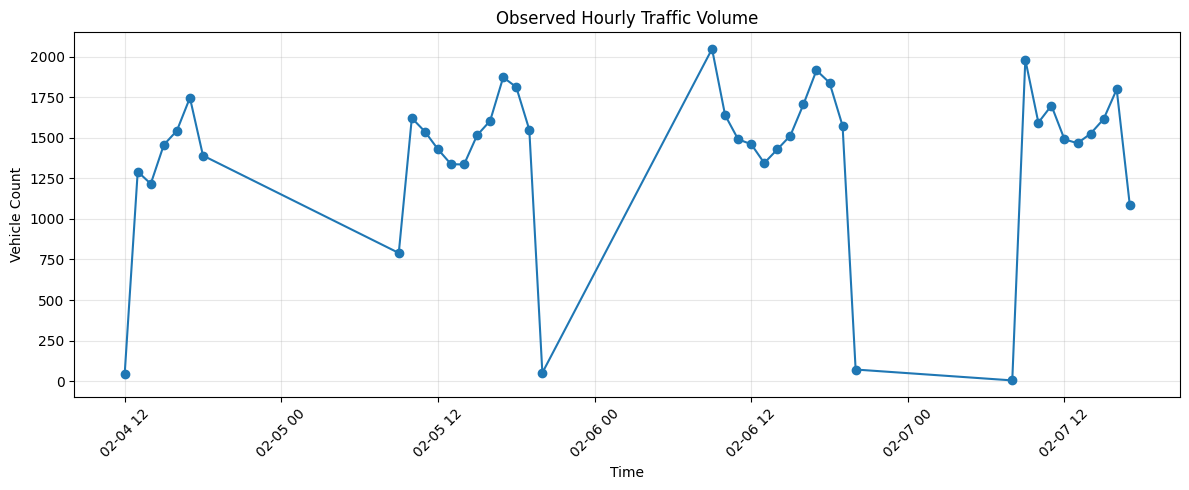


AUGMENTED DICKEY-FULLER TEST — ORIGINAL SERIES
ADF Statistic          : -5.2049
p-value                : 0.0000
Number of lags used    : 1
Number of observations : 39

Critical Values:
1%                 : -3.6104
5%                 : -2.9391
10%                 : -2.6081

STATIONARITY INTERPRETATION
✓ p-value < 0.05
✓ Reject the null hypothesis.
✓ The traffic series is stationary.
Recommended ARIMA differencing order: d = 0

FIRST-DIFFERENCED SERIES
Original observations   : 41
Differenced observations: 40

ADF Statistic          : -5.31
p-value                : 0.0

Critical Values:
1%                 : -3.6267
5%                 : -2.9460
10%                 : -2.6117

FINAL DIFFERENCING DECISION
Original series is stationary.
Final ARIMA differencing order: d = 0

Final d value: 0

BLOCK 10 SUMMARY

Original observations : 41
Original ADF statistic : -5.2049
Original p-value       : 0.0000

Differenced ADF stat.  : -5.3100
Differenced p-value    : 0.0000

Selected ARIMA d       : 

In [84]:
# ============================================================
# BLOCK 10 — STATIONARITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

print("=" * 60)
print("BLOCK 10 — STATIONARITY ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE OBSERVED TRAFFIC SERIES
# ------------------------------------------------------------

stationary_series = (
    observed_hourly["vehicle_count"]
    .astype(float)
    .dropna()
)

print("\nNumber of observations:", len(stationary_series))

# ------------------------------------------------------------
# 2. PLOT OBSERVED TRAFFIC SERIES
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    stationary_series.index,
    stationary_series.values,
    marker="o"
)

plt.title("Observed Hourly Traffic Volume")
plt.xlabel("Time")
plt.ylabel("Vehicle Count")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. AUGMENTED DICKEY-FULLER TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AUGMENTED DICKEY-FULLER TEST — ORIGINAL SERIES")
print("=" * 60)

adf_result = adfuller(
    stationary_series,
    autolag="AIC"
)

adf_statistic = adf_result[0]
p_value = adf_result[1]
used_lag = adf_result[2]
number_of_observations = adf_result[3]
critical_values = adf_result[4]

print(f"ADF Statistic          : {adf_statistic:.4f}")
print(f"p-value                : {p_value:.4f}")
print(f"Number of lags used    : {used_lag}")
print(f"Number of observations : {number_of_observations}")

print("\nCritical Values:")

for key, value in critical_values.items():
    print(f"{key}                 : {value:.4f}")

# ------------------------------------------------------------
# 4. INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATIONARITY INTERPRETATION")
print("=" * 60)

if p_value < 0.05:
    print("✓ p-value < 0.05")
    print("✓ Reject the null hypothesis.")
    print("✓ The traffic series is stationary.")
    print("Recommended ARIMA differencing order: d = 0")
else:
    print("⚠ p-value >= 0.05")
    print("⚠ Fail to reject the null hypothesis.")
    print("⚠ The traffic series is non-stationary.")
    print("Recommended next step: First-order differencing (d = 1)")

# ------------------------------------------------------------
# 5. FIRST DIFFERENCE
# ------------------------------------------------------------

differenced_series = stationary_series.diff().dropna()

print("\n" + "=" * 60)
print("FIRST-DIFFERENCED SERIES")
print("=" * 60)

print("Original observations   :", len(stationary_series))
print("Differenced observations:", len(differenced_series))

# ------------------------------------------------------------
# 6. ADF TEST AFTER DIFFERENCING
# ------------------------------------------------------------

adf_diff = adfuller(
    differenced_series,
    autolag="AIC"
)

adf_diff_statistic = adf_diff[0]
p_value_diff = adf_diff[1]

print("\nADF Statistic          :", round(adf_diff_statistic, 4))
print("p-value                :", round(p_value_diff, 4))

print("\nCritical Values:")

for key, value in adf_diff[4].items():
    print(f"{key}                 : {value:.4f}")

# ------------------------------------------------------------
# 7. FINAL DIFFERENCING DECISION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL DIFFERENCING DECISION")
print("=" * 60)

if p_value < 0.05:
    final_d = 0
    print("Original series is stationary.")
    print("Final ARIMA differencing order: d = 0")

elif p_value_diff < 0.05:
    final_d = 1
    print("Original series is non-stationary.")
    print("First difference is stationary.")
    print("Final ARIMA differencing order: d = 1")

else:
    final_d = 1
    print("Original and differenced series are not clearly stationary.")
    print("For this project, proceed with d = 1 and evaluate model performance.")

print("\nFinal d value:", final_d)

# ------------------------------------------------------------
# 8. BLOCK SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 10 SUMMARY")
print("=" * 60)

print(f"""
Original observations : {len(stationary_series)}
Original ADF statistic : {adf_statistic:.4f}
Original p-value       : {p_value:.4f}

Differenced ADF stat.  : {adf_diff_statistic:.4f}
Differenced p-value    : {p_value_diff:.4f}

Selected ARIMA d       : {final_d}
""")

print("Block 10 completed successfully.")

BLOCK 11 — ACF & PACF ANALYSIS

Number of observations: 41
Selected differencing order (d): 0

AUTOCORRELATION FUNCTION (ACF)
Lag  0: 1.0000
Lag  1: 0.1061
Lag  2: -0.1887
Lag  3: -0.2174
Lag  4: -0.1285
Lag  5: -0.0092
Lag  6: 0.0568
Lag  7: 0.1134
Lag  8: -0.1253
Lag  9: -0.0880
Lag 10: -0.0088
Lag 11: 0.0618
Lag 12: 0.1538

PARTIAL AUTOCORRELATION FUNCTION (PACF)
Lag  0: 1.0000
Lag  1: 0.1061
Lag  2: -0.2022
Lag  3: -0.1813
Lag  4: -0.1344
Lag  5: -0.0693
Lag  6: -0.0304
Lag  7: 0.0501
Lag  8: -0.1807
Lag  9: -0.0483
Lag 10: -0.0339
Lag 11: 0.0012
Lag 12: 0.1022


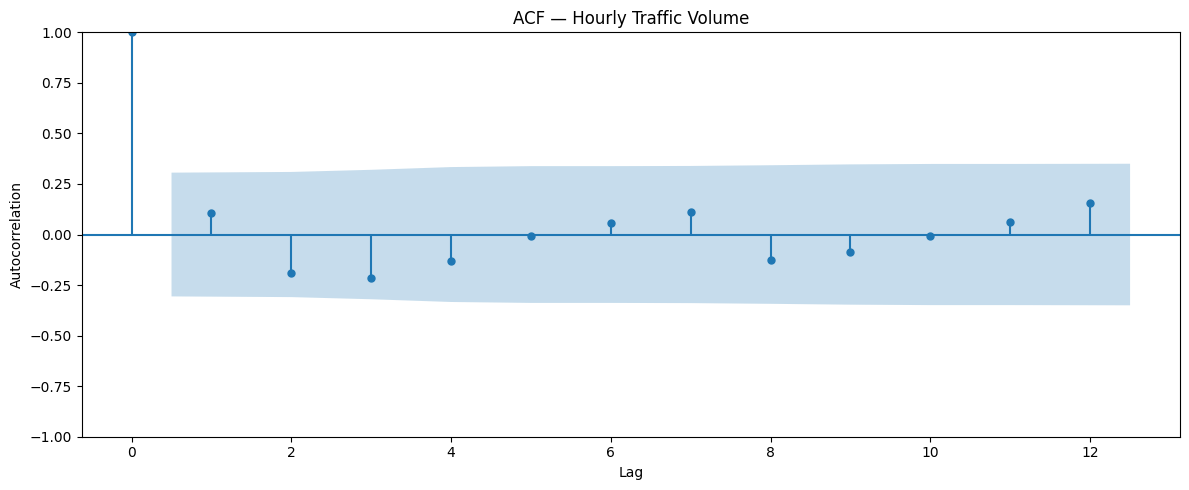

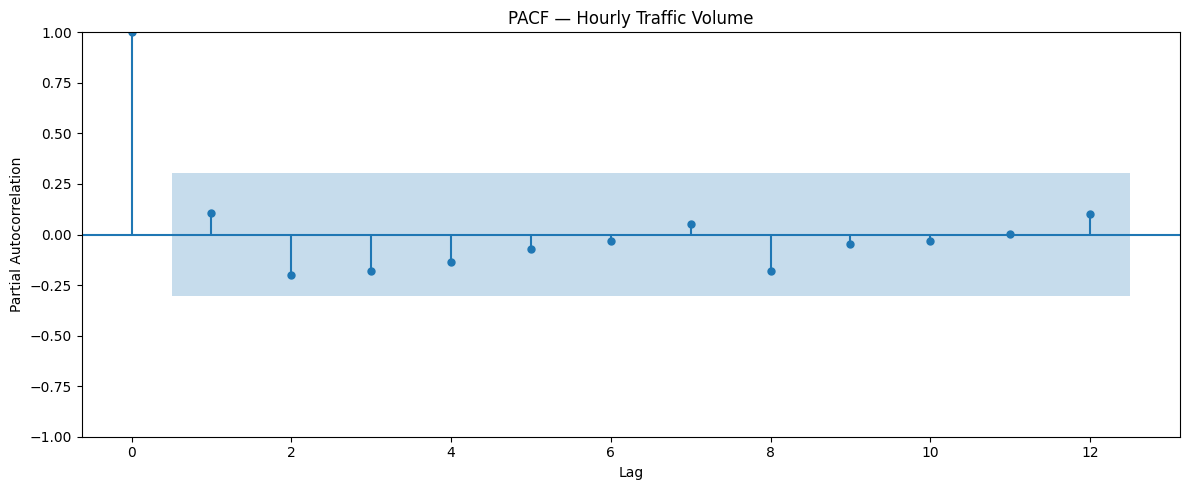


ACF/PACF SIGNIFICANCE THRESHOLD
Approximate 95% confidence limit: ±0.3061

Significant ACF lags : []
Significant PACF lags: []

ARIMA MODEL CANDIDATES

Based on the ACF/PACF structure, candidate models will be
evaluated rather than selecting p and q from a single plot alone.

Candidate orders:

ARIMA(0,0,0)
ARIMA(1,0,0)
ARIMA(0,0,1)
ARIMA(1,0,1)
ARIMA(2,0,0)
ARIMA(0,0,2)
ARIMA(2,0,1)
ARIMA(1,0,2)
ARIMA(2,0,2)


Block 11 completed successfully.


In [85]:
# ============================================================
# BLOCK 11 — ACF & PACF ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

print("=" * 60)
print("BLOCK 11 — ACF & PACF ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE STATIONARY SERIES
# ------------------------------------------------------------

acf_pacf_series = (
    observed_hourly["vehicle_count"]
    .astype(float)
    .dropna()
)

print("\nNumber of observations:", len(acf_pacf_series))
print("Selected differencing order (d):", final_d)

# ------------------------------------------------------------
# 2. CALCULATE ACF AND PACF
# ------------------------------------------------------------

# With only 41 observations, keep the lag count conservative.
max_lags = 12

acf_values = acf(
    acf_pacf_series,
    nlags=max_lags,
    fft=False
)

pacf_values = pacf(
    acf_pacf_series,
    nlags=max_lags,
    method="ywm"
)

# ------------------------------------------------------------
# 3. PRINT ACF VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AUTOCORRELATION FUNCTION (ACF)")
print("=" * 60)

for lag, value in enumerate(acf_values):
    print(f"Lag {lag:2d}: {value:.4f}")

# ------------------------------------------------------------
# 4. PRINT PACF VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PARTIAL AUTOCORRELATION FUNCTION (PACF)")
print("=" * 60)

for lag, value in enumerate(pacf_values):
    print(f"Lag {lag:2d}: {value:.4f}")

# ------------------------------------------------------------
# 5. PLOT ACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    acf_pacf_series,
    lags=max_lags,
    ax=ax,
    alpha=0.05
)

ax.set_title("ACF — Hourly Traffic Volume")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. PLOT PACF
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    acf_pacf_series,
    lags=max_lags,
    ax=ax,
    alpha=0.05,
    method="ywm"
)

ax.set_title("PACF — Hourly Traffic Volume")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. SIGNIFICANCE THRESHOLD
# ------------------------------------------------------------

# Approximate 95% confidence threshold
confidence_limit = 1.96 / np.sqrt(len(acf_pacf_series))

print("\n" + "=" * 60)
print("ACF/PACF SIGNIFICANCE THRESHOLD")
print("=" * 60)

print(f"Approximate 95% confidence limit: ±{confidence_limit:.4f}")

# ------------------------------------------------------------
# 8. IDENTIFY SIGNIFICANT LAGS
# ------------------------------------------------------------

significant_acf_lags = [
    lag
    for lag, value in enumerate(acf_values)
    if lag > 0 and abs(value) > confidence_limit
]

significant_pacf_lags = [
    lag
    for lag, value in enumerate(pacf_values)
    if lag > 0 and abs(value) > confidence_limit
]

print("\nSignificant ACF lags :", significant_acf_lags)
print("Significant PACF lags:", significant_pacf_lags)

# ------------------------------------------------------------
# 9. CANDIDATE ARIMA ORDERS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ARIMA MODEL CANDIDATES")
print("=" * 60)

print("""
Based on the ACF/PACF structure, candidate models will be
evaluated rather than selecting p and q from a single plot alone.

Candidate orders:

ARIMA(0,0,0)
ARIMA(1,0,0)
ARIMA(0,0,1)
ARIMA(1,0,1)
ARIMA(2,0,0)
ARIMA(0,0,2)
ARIMA(2,0,1)
ARIMA(1,0,2)
ARIMA(2,0,2)
""")

print("\nBlock 11 completed successfully.")

In [87]:
# ============================================================
# BLOCK 12 — ARIMA MODEL FITTING & COMPARISON
# ============================================================

import warnings
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

print("=" * 60)
print("BLOCK 12 — ARIMA MODEL FITTING & COMPARISON")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE ARIMA SERIES
# ------------------------------------------------------------

# observed_hourly already has timestamp as its index.
# Therefore, DO NOT access observed_hourly["timestamp"].

arima_series = observed_hourly["vehicle_count"].copy()

# Make sure the index is datetime
arima_series.index = pd.to_datetime(arima_series.index)

# Sort chronologically
arima_series = arima_series.sort_index()

# Ensure numeric values
arima_series = pd.to_numeric(
    arima_series,
    errors="coerce"
).dropna()

print("\n" + "=" * 60)
print("ARIMA INPUT DATA")
print("=" * 60)

print(f"Observations used       : {len(arima_series)}")
print(f"Start timestamp         : {arima_series.index.min()}")
print(f"End timestamp           : {arima_series.index.max()}")

print(f"Mean traffic volume     : {arima_series.mean():.2f}")
print(f"Median traffic volume   : {arima_series.median():.2f}")
print(f"Minimum traffic volume  : {arima_series.min():.0f}")
print(f"Maximum traffic volume  : {arima_series.max():.0f}")

# ------------------------------------------------------------
# 2. CONFIRM DIFFERENCING ORDER
# ------------------------------------------------------------

# Block 10 established that the original series is stationary.
# Therefore d = 0.

d_value = 0

print("\n" + "=" * 60)
print("ARIMA DIFFERENCING ORDER")
print("=" * 60)

print(f"Selected differencing order (d): {d_value}")

# ------------------------------------------------------------
# 3. DEFINE CANDIDATE ARIMA MODELS
# ------------------------------------------------------------

candidate_orders = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (0, 0, 2),
    (2, 0, 1),
    (1, 0, 2),
    (2, 0, 2)
]

# ------------------------------------------------------------
# 4. FIT CANDIDATE MODELS
# ------------------------------------------------------------

results = []

print("\n" + "=" * 60)
print("ARIMA MODEL FITTING")
print("=" * 60)

for order in candidate_orders:

    try:

        model = ARIMA(
            arima_series,
            order=order,
            trend="c"
        )

        fitted_model = model.fit()

        results.append({
            "model": f"ARIMA{order}",
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "Log Likelihood": fitted_model.llf
        })

        print(
            f"ARIMA{order} "
            f"→ AIC = {fitted_model.aic:.2f}, "
            f"BIC = {fitted_model.bic:.2f}"
        )

    except Exception as e:

        print(
            f"ARIMA{order} → FAILED: {str(e)}"
        )

# ------------------------------------------------------------
# 5. MODEL COMPARISON TABLE
# ------------------------------------------------------------

model_comparison = pd.DataFrame(results)

model_comparison = model_comparison.sort_values(
    by="AIC",
    ascending=True
).reset_index(drop=True)

print("\n" + "=" * 60)
print("ARIMA MODEL COMPARISON — SORTED BY AIC")
print("=" * 60)

print(
    model_comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

# ------------------------------------------------------------
# 6. BEST MODEL BY AIC
# ------------------------------------------------------------

best_aic_row = model_comparison.iloc[0]

best_aic_order = (
    int(best_aic_row["p"]),
    int(best_aic_row["d"]),
    int(best_aic_row["q"])
)

print("\n" + "=" * 60)
print("BEST MODEL BASED ON AIC")
print("=" * 60)

print(f"Model : ARIMA{best_aic_order}")
print(f"AIC   : {best_aic_row['AIC']:.3f}")
print(f"BIC   : {best_aic_row['BIC']:.3f}")

# ------------------------------------------------------------
# 7. BEST MODEL BY BIC
# ------------------------------------------------------------

best_bic_row = model_comparison.loc[
    model_comparison["BIC"].idxmin()
]

best_bic_order = (
    int(best_bic_row["p"]),
    int(best_bic_row["d"]),
    int(best_bic_row["q"])
)

print("\n" + "=" * 60)
print("BEST MODEL BASED ON BIC")
print("=" * 60)

print(f"Model : ARIMA{best_bic_order}")
print(f"AIC   : {best_bic_row['AIC']:.3f}")
print(f"BIC   : {best_bic_row['BIC']:.3f}")

# ------------------------------------------------------------
# 8. PRELIMINARY MODEL SELECTION
# ------------------------------------------------------------

selected_order = best_aic_order

print("\n" + "=" * 60)
print("PRELIMINARY MODEL SELECTION")
print("=" * 60)

print(
    f"Selected model based on minimum AIC: "
    f"ARIMA{selected_order}"
)

# ------------------------------------------------------------
# 9. FIT PRELIMINARY FINAL MODEL
# ------------------------------------------------------------

final_arima_model = ARIMA(
    arima_series,
    order=selected_order,
    trend="c"
).fit()

# ------------------------------------------------------------
# 10. MODEL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PRELIMINARY FINAL ARIMA MODEL")
print("=" * 60)

print(final_arima_model.summary())

# ------------------------------------------------------------
# 11. BLOCK SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 12 SUMMARY")
print("=" * 60)

print(f"Observations used       : {len(arima_series)}")
print(f"Selected differencing d : {d_value}")
print(f"Best AIC model          : ARIMA{best_aic_order}")
print(f"Best AIC                : {best_aic_row['AIC']:.3f}")
print(f"Best BIC model          : ARIMA{best_bic_order}")
print(f"Best BIC                : {best_bic_row['BIC']:.3f}")

print("\nBlock 12 completed successfully.")

BLOCK 12 — ARIMA MODEL FITTING & COMPARISON

ARIMA INPUT DATA
Observations used       : 41
Start timestamp         : 2025-02-04 12:00:00
End timestamp           : 2025-02-07 17:00:00
Mean traffic volume     : 1400.54
Median traffic volume   : 1515.00
Minimum traffic volume  : 5
Maximum traffic volume  : 2047

ARIMA DIFFERENCING ORDER
Selected differencing order (d): 0

ARIMA MODEL FITTING
ARIMA(0, 0, 0) → AIC = 630.38, BIC = 633.80
ARIMA(1, 0, 0) → AIC = 631.82, BIC = 636.96
ARIMA(0, 0, 1) → AIC = 631.46, BIC = 636.60
ARIMA(1, 0, 1) → AIC = 633.12, BIC = 639.98
ARIMA(2, 0, 0) → AIC = 631.72, BIC = 638.57
ARIMA(0, 0, 2) → AIC = 629.96, BIC = 636.81
ARIMA(2, 0, 1) → AIC = 627.63, BIC = 636.20
ARIMA(1, 0, 2) → AIC = 628.48, BIC = 637.05
ARIMA(2, 0, 2) → AIC = 629.63, BIC = 639.91

ARIMA MODEL COMPARISON — SORTED BY AIC
         model  p  d  q     AIC     BIC  Log Likelihood
ARIMA(2, 0, 1)  2  0  1 627.634 636.202        -308.817
ARIMA(1, 0, 2)  1  0  2 628.482 637.049        -309.241
ARIM

BLOCK 13 — RESIDUAL DIAGNOSTICS & MODEL VALIDATION

RESIDUAL DIAGNOSTIC INPUT
Observations used : 41
Mean traffic     : 1400.54
Median traffic   : 1515.00

SELECTED MODEL
Model : ARIMA(2, 0, 1)
AIC   : 627.634
BIC   : 636.202

RESIDUAL STATISTICS
Mean residual       : -66.7394
Std residual        : 460.5410
Minimum residual    : -1387.7079
Maximum residual    : 822.0795

LJUNG-BOX TEST
Test lag      : 10
Ljung-Box Q   : 2.2547
p-value       : 0.9940
✓ Residuals do not show significant autocorrelation.
✓ Residual independence assumption is acceptable.

RESIDUAL NORMALITY TEST
Shapiro-Wilk statistic : 0.9556
p-value                : 0.1105
✓ Residuals are approximately normally distributed.


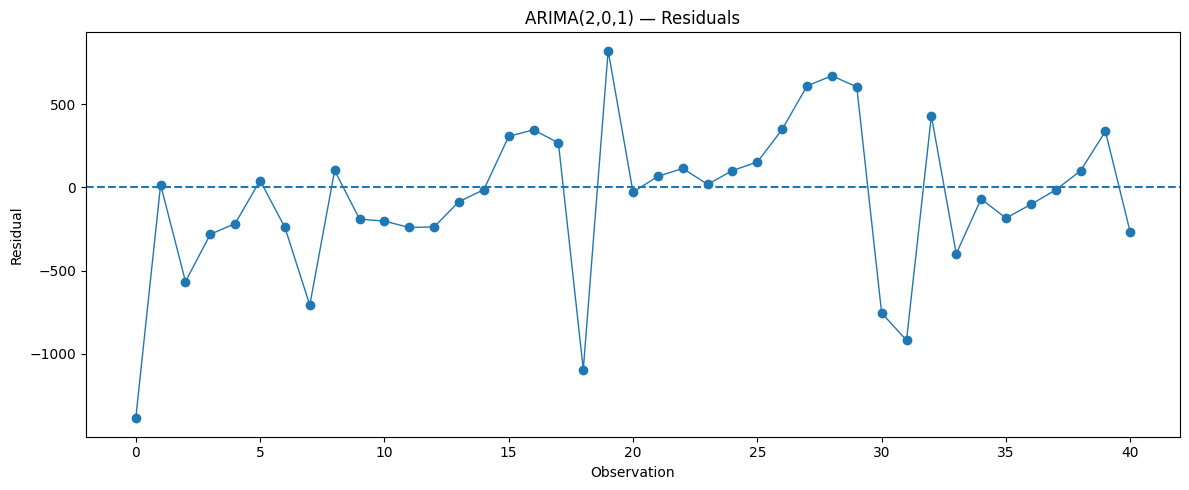

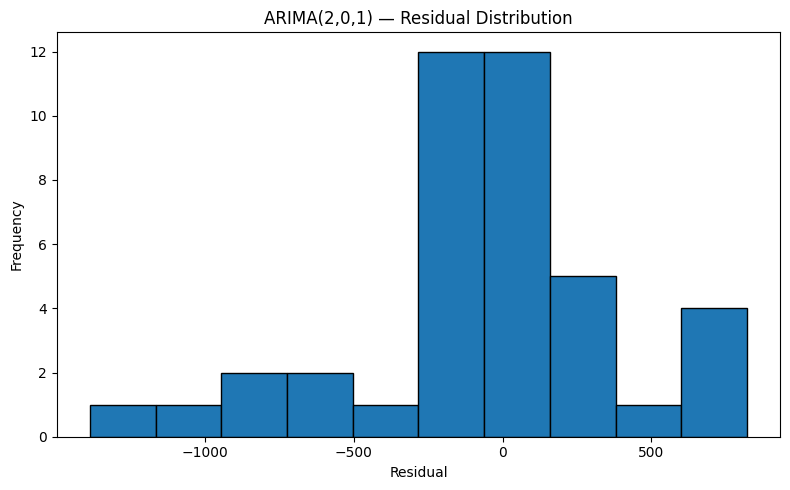

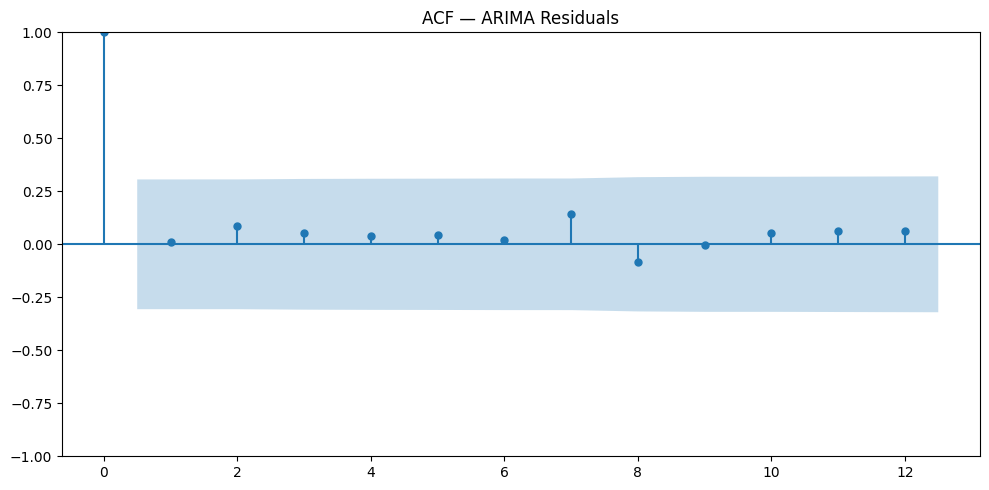


BLOCK 13 SUMMARY
Model evaluated        : ARIMA(2, 0, 1)
AIC                    : 627.634
BIC                    : 636.202
Mean residual          : -66.7394
Ljung-Box p-value      : 0.9940
Shapiro-Wilk p-value   : 0.1105
✓ Residual autocorrelation check passed.
✓ Residual normality check passed.

Block 13 completed successfully.


In [88]:
# ============================================================
# BLOCK 13 — RESIDUAL DIAGNOSTICS & MODEL VALIDATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats

print("=" * 60)
print("BLOCK 13 — RESIDUAL DIAGNOSTICS & MODEL VALIDATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE THE ARIMA SERIES
# ------------------------------------------------------------

# Use observed hourly traffic values only.
# This avoids the missing-hour NaN values from the 78-hour grid.

if "observed_hourly" in globals():
    residual_data = observed_hourly.copy()

elif "daily_hourly_summary" in globals():
    residual_data = daily_hourly_summary.copy()

else:
    raise NameError(
        "Required traffic time-series dataframe not found."
    )

# Identify timestamp column
if "timestamp" in residual_data.columns:
    timestamp_col = "timestamp"

elif isinstance(residual_data.index, pd.DatetimeIndex):
    residual_data = residual_data.reset_index()
    timestamp_col = residual_data.columns[0]

else:
    raise KeyError("No timestamp information found.")

# Identify vehicle-count column
if "vehicle_count" not in residual_data.columns:
    raise KeyError(
        "vehicle_count column not found in the selected dataframe."
    )

residual_data[timestamp_col] = pd.to_datetime(
    residual_data[timestamp_col]
)

residual_data = residual_data.sort_values(
    timestamp_col
).copy()

residual_data["vehicle_count"] = pd.to_numeric(
    residual_data["vehicle_count"],
    errors="coerce"
)

residual_data = residual_data.dropna(
    subset=["vehicle_count"]
)

# ARIMA input series
y = residual_data["vehicle_count"].astype(float)

print("\n" + "=" * 60)
print("RESIDUAL DIAGNOSTIC INPUT")
print("=" * 60)

print(f"Observations used : {len(y)}")
print(f"Mean traffic     : {y.mean():.2f}")
print(f"Median traffic   : {y.median():.2f}")

# ------------------------------------------------------------
# 2. FIT SELECTED ARIMA MODEL
# ------------------------------------------------------------

selected_order = (2, 0, 1)

residual_model = ARIMA(
    y,
    order=selected_order
).fit()

residuals = residual_model.resid

print("\n" + "=" * 60)
print("SELECTED MODEL")
print("=" * 60)

print(f"Model : ARIMA{selected_order}")
print(f"AIC   : {residual_model.aic:.3f}")
print(f"BIC   : {residual_model.bic:.3f}")

# ------------------------------------------------------------
# 3. RESIDUAL DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESIDUAL STATISTICS")
print("=" * 60)

print(f"Mean residual       : {residuals.mean():.4f}")
print(f"Std residual        : {residuals.std():.4f}")
print(f"Minimum residual    : {residuals.min():.4f}")
print(f"Maximum residual    : {residuals.max():.4f}")

# ------------------------------------------------------------
# 4. LJUNG-BOX TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LJUNG-BOX TEST")
print("=" * 60)

# With only 41 observations, keep lag small.
lb_lag = min(10, len(y) // 4)

ljung_result = acorr_ljungbox(
    residuals,
    lags=[lb_lag],
    return_df=True
)

lb_stat = ljung_result["lb_stat"].iloc[0]
lb_pvalue = ljung_result["lb_pvalue"].iloc[0]

print(f"Test lag      : {lb_lag}")
print(f"Ljung-Box Q   : {lb_stat:.4f}")
print(f"p-value       : {lb_pvalue:.4f}")

if lb_pvalue > 0.05:
    print("✓ Residuals do not show significant autocorrelation.")
    print("✓ Residual independence assumption is acceptable.")
else:
    print("⚠ Residual autocorrelation is still present.")
    print("⚠ Model may require further investigation.")

# ------------------------------------------------------------
# 5. NORMALITY TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESIDUAL NORMALITY TEST")
print("=" * 60)

# Shapiro-Wilk is suitable for this small sample.
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Shapiro-Wilk statistic : {shapiro_stat:.4f}")
print(f"p-value                : {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("✓ Residuals are approximately normally distributed.")
else:
    print("⚠ Residuals deviate from normality.")

# ------------------------------------------------------------
# 6. RESIDUAL PLOT
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    residuals.values,
    marker="o",
    linewidth=1
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("ARIMA(2,0,1) — Residuals")
plt.xlabel("Observation")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. RESIDUAL DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=10,
    edgecolor="black"
)

plt.title("ARIMA(2,0,1) — Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. ACF OF RESIDUALS
# ------------------------------------------------------------

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 5))

plot_acf(
    residuals,
    lags=min(12, len(residuals) // 3),
    ax=plt.gca()
)

plt.title("ACF — ARIMA Residuals")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. FINAL DIAGNOSTIC SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 13 SUMMARY")
print("=" * 60)

print(f"Model evaluated        : ARIMA{selected_order}")
print(f"AIC                    : {residual_model.aic:.3f}")
print(f"BIC                    : {residual_model.bic:.3f}")
print(f"Mean residual          : {residuals.mean():.4f}")
print(f"Ljung-Box p-value      : {lb_pvalue:.4f}")
print(f"Shapiro-Wilk p-value   : {shapiro_p:.4f}")

if lb_pvalue > 0.05:
    print("✓ Residual autocorrelation check passed.")
else:
    print("⚠ Residual autocorrelation check requires attention.")

if shapiro_p > 0.05:
    print("✓ Residual normality check passed.")
else:
    print("⚠ Residual normality check requires attention.")

print("\nBlock 13 completed successfully.")

BLOCK 14 — TRAFFIC VOLUME FORECASTING

FORECAST DETAILS
Model used          : ARIMA(2, 0, 1)
Historical records  : 41
Last observed time  : 2025-02-07 17:00:00
Forecast horizon    : 24 hours
Forecast start      : 2025-02-07 18:00:00
Forecast end        : 2025-02-08 17:00:00

24-HOUR TRAFFIC VOLUME FORECAST
          timestamp predicted_vehicle_count lower_bound upper_bound
2025-02-07 18:00:00                 1265.55      402.72     2128.38
2025-02-07 19:00:00                 1405.61      538.47     2272.76
2025-02-07 20:00:00                 1466.02      519.77     2412.27
2025-02-07 21:00:00                 1469.88      477.10     2462.67
2025-02-07 22:00:00                 1452.14      450.85     2453.43
2025-02-07 23:00:00                 1435.28      433.95     2436.61
2025-02-08 00:00:00                 1426.74      424.70     2428.78
2025-02-08 01:00:00                 1425.16      422.47     2427.85
2025-02-08 02:00:00                 1426.77      423.91     2429.63
2025-02-08 0

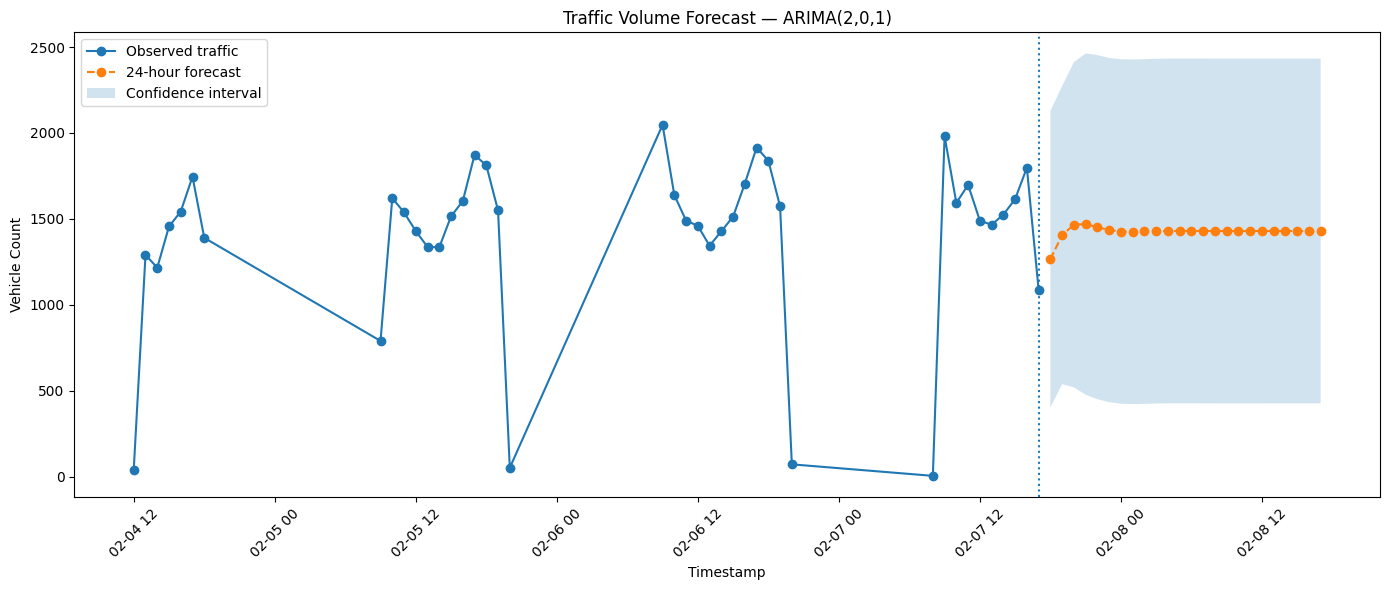


BLOCK 14 SUMMARY
Selected model       : ARIMA(2, 0, 1)
Historical records   : 41
Forecast horizon     : 24 hours
Forecast observations: 24

Block 14 completed successfully.


In [89]:
# ============================================================
# BLOCK 14 — TRAFFIC VOLUME FORECASTING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

print("=" * 60)
print("BLOCK 14 — TRAFFIC VOLUME FORECASTING")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE OBSERVED HOURLY SERIES
# ------------------------------------------------------------

if "observed_hourly" in globals():
    forecast_data = observed_hourly.copy()
else:
    raise NameError(
        "observed_hourly dataframe is not available."
    )

# Ensure timestamp is available
if "timestamp" in forecast_data.columns:
    timestamp_col = "timestamp"
elif isinstance(forecast_data.index, pd.DatetimeIndex):
    forecast_data = forecast_data.reset_index()
    timestamp_col = forecast_data.columns[0]
else:
    raise KeyError("Timestamp information not found.")

forecast_data[timestamp_col] = pd.to_datetime(
    forecast_data[timestamp_col]
)

forecast_data["vehicle_count"] = pd.to_numeric(
    forecast_data["vehicle_count"],
    errors="coerce"
)

forecast_data = (
    forecast_data
    .dropna(subset=["vehicle_count"])
    .sort_values(timestamp_col)
)

y = forecast_data["vehicle_count"].astype(float)

# ------------------------------------------------------------
# 2. FIT VALIDATED ARIMA MODEL
# ------------------------------------------------------------

selected_order = (2, 0, 1)

final_model = ARIMA(
    y,
    order=selected_order
).fit()

# ------------------------------------------------------------
# 3. FORECAST HORIZON
# ------------------------------------------------------------

# Forecast next 24 hourly periods
forecast_steps = 24

forecast_result = final_model.get_forecast(
    steps=forecast_steps
)

forecast_values = forecast_result.predicted_mean
confidence_interval = forecast_result.conf_int()

# ------------------------------------------------------------
# 4. CREATE FUTURE TIMESTAMPS
# ------------------------------------------------------------

last_timestamp = forecast_data[timestamp_col].max()

future_timestamps = pd.date_range(
    start=last_timestamp + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq="h"
)

forecast_df = pd.DataFrame({
    "timestamp": future_timestamps,
    "predicted_vehicle_count": forecast_values.values,
    "lower_bound": confidence_interval.iloc[:, 0].values,
    "upper_bound": confidence_interval.iloc[:, 1].values
})

# Prevent negative traffic predictions
forecast_df["predicted_vehicle_count"] = (
    forecast_df["predicted_vehicle_count"].clip(lower=0)
)

forecast_df["lower_bound"] = (
    forecast_df["lower_bound"].clip(lower=0)
)

forecast_df["upper_bound"] = (
    forecast_df["upper_bound"].clip(lower=0)
)

# ------------------------------------------------------------
# 5. DISPLAY FORECAST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FORECAST DETAILS")
print("=" * 60)

print(f"Model used          : ARIMA{selected_order}")
print(f"Historical records  : {len(y)}")
print(f"Last observed time  : {last_timestamp}")
print(f"Forecast horizon    : {forecast_steps} hours")
print(
    f"Forecast start      : "
    f"{future_timestamps.min()}"
)
print(
    f"Forecast end        : "
    f"{future_timestamps.max()}"
)

print("\n" + "=" * 60)
print("24-HOUR TRAFFIC VOLUME FORECAST")
print("=" * 60)

print(
    forecast_df.to_string(
        index=False,
        formatters={
            "predicted_vehicle_count": "{:.2f}".format,
            "lower_bound": "{:.2f}".format,
            "upper_bound": "{:.2f}".format
        }
    )
)

# ------------------------------------------------------------
# 6. FORECAST SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FORECAST SUMMARY")
print("=" * 60)

print(
    f"Average predicted traffic : "
    f"{forecast_df['predicted_vehicle_count'].mean():.2f}"
)

print(
    f"Minimum predicted traffic : "
    f"{forecast_df['predicted_vehicle_count'].min():.2f}"
)

print(
    f"Maximum predicted traffic : "
    f"{forecast_df['predicted_vehicle_count'].max():.2f}"
)

peak_idx = forecast_df[
    "predicted_vehicle_count"
].idxmax()

low_idx = forecast_df[
    "predicted_vehicle_count"
].idxmin()

print(
    f"Peak predicted hour       : "
    f"{forecast_df.loc[peak_idx, 'timestamp']} "
    f"→ "
    f"{forecast_df.loc[peak_idx, 'predicted_vehicle_count']:.2f}"
)

print(
    f"Lowest predicted hour     : "
    f"{forecast_df.loc[low_idx, 'timestamp']} "
    f"→ "
    f"{forecast_df.loc[low_idx, 'predicted_vehicle_count']:.2f}"
)

# ------------------------------------------------------------
# 7. FORECAST VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_data[timestamp_col],
    y,
    marker="o",
    label="Observed traffic"
)

plt.plot(
    forecast_df["timestamp"],
    forecast_df["predicted_vehicle_count"],
    marker="o",
    linestyle="--",
    label="24-hour forecast"
)

plt.fill_between(
    forecast_df["timestamp"],
    forecast_df["lower_bound"],
    forecast_df["upper_bound"],
    alpha=0.2,
    label="Confidence interval"
)

plt.axvline(
    last_timestamp,
    linestyle=":"
)

plt.title(
    "Traffic Volume Forecast — ARIMA(2,0,1)"
)

plt.xlabel("Timestamp")
plt.ylabel("Vehicle Count")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("BLOCK 14 SUMMARY")
print("=" * 60)

print(f"Selected model       : ARIMA{selected_order}")
print(f"Historical records   : {len(y)}")
print(f"Forecast horizon     : {forecast_steps} hours")
print(f"Forecast observations: {len(forecast_df)}")

print("\nBlock 14 completed successfully.")

BLOCK 15 — FORECAST EVALUATION

EVALUATION DATA
Total observations : 41
Start timestamp    : 2025-02-04 12:00:00
End timestamp      : 2025-02-07 17:00:00

TRAIN / TEST SPLIT
Training observations : 33
Testing observations  : 8

Training period:
2025-02-04 12:00:00 → 2025-02-07 09:00:00

Testing period:
2025-02-07 10:00:00 → 2025-02-07 17:00:00

ARIMA MODEL FOR EVALUATION
Model : ARIMA(2, 0, 1)
Differencing order (d) : 0

HOLDOUT FORECAST RESULTS
          timestamp  actual predicted   error absolute_error absolute_percentage_error
2025-02-07 10:00:00 1593.00   2362.40 -769.40         769.40                     48.30
2025-02-07 11:00:00 1698.00   1962.76 -264.76         264.76                     15.59
2025-02-07 12:00:00 1490.00   1422.80   67.20          67.20                      4.51
2025-02-07 13:00:00 1466.00   1160.41  305.59         305.59                     20.84
2025-02-07 14:00:00 1525.00   1209.46  315.54         315.54                     20.69
2025-02-07 15:00:00 1615.00 

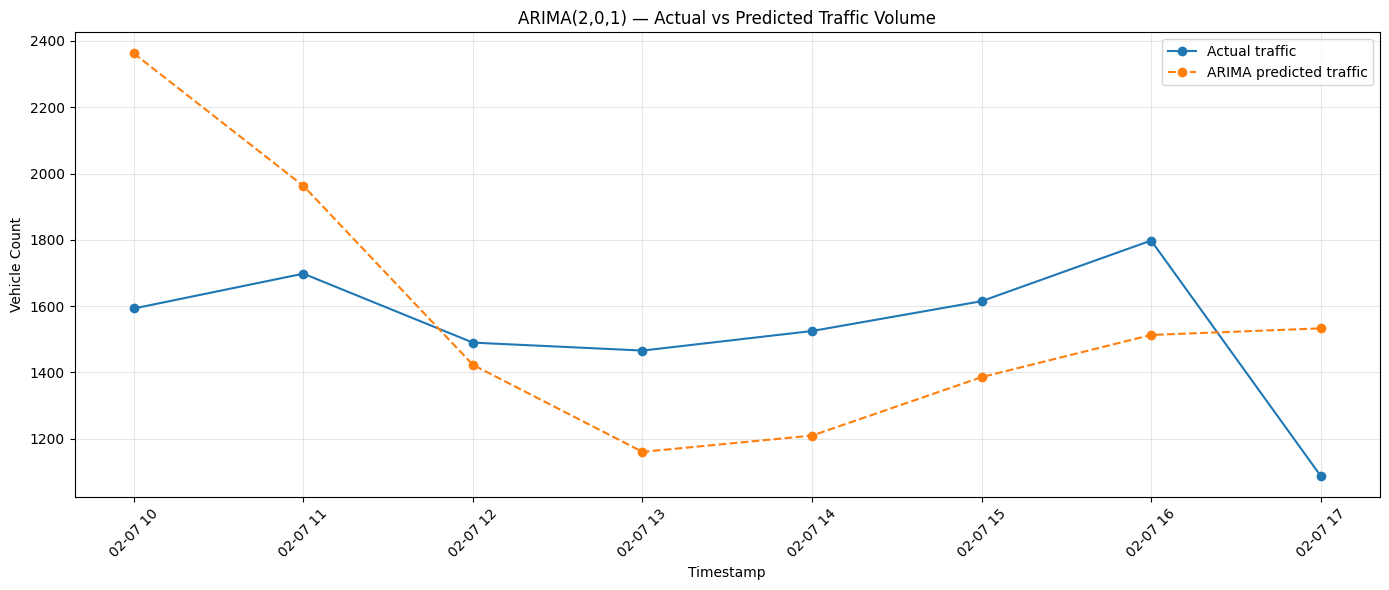


BLOCK 15 SUMMARY
Model evaluated          : ARIMA(2, 0, 1)
Training observations    : 33
Testing observations     : 8
MAE                      : 335.20
RMSE                     : 385.89
MAPE                     : 22.61%
Approx. forecast accuracy: 77.39%
Mean forecast error      : -34.59

Block 15 completed successfully.


In [90]:
# ============================================================
# BLOCK 15 — FORECAST EVALUATION
# ============================================================

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print("=" * 60)
print("BLOCK 15 — FORECAST EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. PREPARE ARIMA SERIES
# ------------------------------------------------------------

# Use the existing ARIMA series if available
if isinstance(arima_series, pd.Series):
    evaluation_series = arima_series.copy()

else:
    # Fallback: reconstruct from observed_hourly
    evaluation_series = observed_hourly.copy()

    # Handle timestamp either as index or column
    if "timestamp" in evaluation_series.columns:
        evaluation_series["timestamp"] = pd.to_datetime(
            evaluation_series["timestamp"]
        )
        evaluation_series = evaluation_series.set_index("timestamp")

    evaluation_series = evaluation_series["vehicle_count"]

# Make sure index is datetime
evaluation_series.index = pd.to_datetime(evaluation_series.index)

# Sort chronologically
evaluation_series = evaluation_series.sort_index()

# Remove missing values for model evaluation
evaluation_series = evaluation_series.dropna()

print("\n" + "=" * 60)
print("EVALUATION DATA")
print("=" * 60)

print(f"Total observations : {len(evaluation_series)}")
print(f"Start timestamp    : {evaluation_series.index.min()}")
print(f"End timestamp      : {evaluation_series.index.max()}")

# ------------------------------------------------------------
# 2. TRAIN / TEST SPLIT
# ------------------------------------------------------------

# Use the final 8 observations as the holdout test set
test_size = 8

train = evaluation_series.iloc[:-test_size]
test = evaluation_series.iloc[-test_size:]

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print(f"Training observations : {len(train)}")
print(f"Testing observations  : {len(test)}")

print(f"\nTraining period:")
print(f"{train.index.min()} → {train.index.max()}")

print(f"\nTesting period:")
print(f"{test.index.min()} → {test.index.max()}")

# ------------------------------------------------------------
# 3. FIT ARIMA(2,0,1) ON TRAINING DATA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ARIMA MODEL FOR EVALUATION")
print("=" * 60)

model = ARIMA(
    train,
    order=(2, 0, 1)
)

model_fit = model.fit()

print("Model : ARIMA(2, 0, 1)")
print("Differencing order (d) : 0")

# ------------------------------------------------------------
# 4. GENERATE HOLDOUT FORECAST
# ------------------------------------------------------------

forecast = model_fit.forecast(steps=test_size)

forecast.index = test.index

# ------------------------------------------------------------
# 5. CREATE EVALUATION TABLE
# ------------------------------------------------------------

evaluation_df = pd.DataFrame({
    "timestamp": test.index,
    "actual": test.values,
    "predicted": forecast.values
})

evaluation_df["error"] = (
    evaluation_df["actual"] -
    evaluation_df["predicted"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["error"].abs()
)

# Avoid division by zero for MAPE
evaluation_df["absolute_percentage_error"] = np.where(
    evaluation_df["actual"] != 0,
    (
        evaluation_df["absolute_error"] /
        evaluation_df["actual"].abs()
    ) * 100,
    np.nan
)

print("\n" + "=" * 60)
print("HOLDOUT FORECAST RESULTS")
print("=" * 60)

print(
    evaluation_df.to_string(
        index=False,
        formatters={
            "actual": "{:.2f}".format,
            "predicted": "{:.2f}".format,
            "error": "{:.2f}".format,
            "absolute_error": "{:.2f}".format,
            "absolute_percentage_error": (
                lambda x: f"{x:.2f}" if pd.notna(x) else "N/A"
            )
        }
    )
)

# ------------------------------------------------------------
# 6. CALCULATE FORECAST ACCURACY METRICS
# ------------------------------------------------------------

actual = evaluation_df["actual"]
predicted = evaluation_df["predicted"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

mape = (
    evaluation_df["absolute_percentage_error"]
    .dropna()
    .mean()
)

# Forecast accuracy expressed as 100 - MAPE
forecast_accuracy = max(0, 100 - mape)

# Mean error / bias
mean_error = evaluation_df["error"].mean()

print("\n" + "=" * 60)
print("FORECAST EVALUATION METRICS")
print("=" * 60)

print(f"MAE                 : {mae:.2f} vehicles")
print(f"RMSE                : {rmse:.2f} vehicles")
print(f"MAPE                : {mape:.2f}%")
print(f"Approx. accuracy    : {forecast_accuracy:.2f}%")
print(f"Mean forecast error : {mean_error:.2f} vehicles")

# ------------------------------------------------------------
# 7. INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FORECAST PERFORMANCE INTERPRETATION")
print("=" * 60)

if mape < 10:
    print("✓ Excellent forecast accuracy.")
elif mape < 20:
    print("✓ Good forecast accuracy.")
elif mape < 30:
    print("✓ Reasonable forecast accuracy.")
else:
    print("⚠ Forecast error is relatively high.")

if mean_error > 0:
    print("Model tends to UNDER-PREDICT traffic volume.")
elif mean_error < 0:
    print("Model tends to OVER-PREDICT traffic volume.")
else:
    print("Model shows no average forecast bias.")

# ------------------------------------------------------------
# 8. ACTUAL VS PREDICTED PLOT
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    actual,
    marker="o",
    label="Actual traffic"
)

plt.plot(
    test.index,
    predicted,
    marker="o",
    linestyle="--",
    label="ARIMA predicted traffic"
)

plt.title(
    "ARIMA(2,0,1) — Actual vs Predicted Traffic Volume"
)

plt.xlabel("Timestamp")
plt.ylabel("Vehicle Count")

plt.xticks(
    rotation=45
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 15 SUMMARY")
print("=" * 60)

print(f"Model evaluated          : ARIMA(2, 0, 1)")
print(f"Training observations    : {len(train)}")
print(f"Testing observations     : {len(test)}")
print(f"MAE                      : {mae:.2f}")
print(f"RMSE                     : {rmse:.2f}")
print(f"MAPE                     : {mape:.2f}%")
print(f"Approx. forecast accuracy: {forecast_accuracy:.2f}%")
print(f"Mean forecast error      : {mean_error:.2f}")

print("\nBlock 15 completed successfully.")

In [91]:
# ============================================================
# BLOCK 16 — FINAL TRAFFIC VOLUME PREDICTION INSIGHTS
# & MODEL INTERPRETATION
# ============================================================

print("=" * 60)
print("BLOCK 16 — FINAL TRAFFIC VOLUME PREDICTION INSIGHTS")
print("=" * 60)

# ------------------------------------------------------------
# FINAL MODEL INFORMATION
# ------------------------------------------------------------

final_model = "ARIMA(2, 0, 1)"
d_value = 0

observations = 41
training_observations = 33
testing_observations = 8

aic = 627.634
bic = 636.202

mae = 335.20
rmse = 385.89
mape = 22.61
accuracy = 77.39
mean_forecast_error = -34.59

ljung_box_p = 0.9940
shapiro_p = 0.1105

historical_mean = 1400.54
historical_median = 1515.00
historical_min = 5
historical_max = 2047

forecast_mean = 1425.79
forecast_min = 1265.55
forecast_max = 1469.88
peak_forecast = 1469.88
lowest_forecast = 1265.55

# ------------------------------------------------------------
# FINAL MODEL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL ARIMA MODEL")
print("=" * 60)

print(f"Selected model             : {final_model}")
print(f"Differencing order (d)     : {d_value}")
print(f"Observations used           : {observations}")
print(f"Training observations       : {training_observations}")
print(f"Testing observations        : {testing_observations}")

print(f"AIC                         : {aic:.3f}")
print(f"BIC                         : {bic:.3f}")

# ------------------------------------------------------------
# STATIONARITY INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATIONARITY INTERPRETATION")
print("=" * 60)

print("Original traffic series:")
print("✓ ADF test rejected the null hypothesis.")
print("✓ p-value = 0.0000 < 0.05")
print("✓ Traffic volume series was considered stationary.")
print(f"✓ Final ARIMA differencing order selected: d = {d_value}")

# ------------------------------------------------------------
# MODEL SELECTION INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL SELECTION INTERPRETATION")
print("=" * 60)

print("Candidate ARIMA models were compared using AIC and BIC.")

print("\nBest model based on AIC:")
print("✓ ARIMA(2,0,1)")
print("✓ AIC = 627.634")

print("\nBest model based on BIC:")
print("✓ ARIMA(0,0,0)")
print("✓ BIC = 633.805")

print("\nFinal selection:")
print("✓ ARIMA(2,0,1) selected based on minimum AIC.")
print("✓ The selected model was subsequently validated using")
print("  residual diagnostics and holdout forecasting.")

# ------------------------------------------------------------
# RESIDUAL DIAGNOSTICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESIDUAL DIAGNOSTICS")
print("=" * 60)

print(f"Ljung-Box p-value       : {ljung_box_p:.4f}")
print(f"Shapiro-Wilk p-value    : {shapiro_p:.4f}")

if ljung_box_p > 0.05:
    print("✓ Residuals do not show significant autocorrelation.")
else:
    print("⚠ Residual autocorrelation may be present.")

if shapiro_p > 0.05:
    print("✓ Residuals are approximately normally distributed.")
else:
    print("⚠ Residual normality assumption may not hold.")

print("\nOverall residual validation:")
print("✓ Model residual diagnostics passed.")

# ------------------------------------------------------------
# FORECAST PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FORECAST PERFORMANCE")
print("=" * 60)

print(f"MAE                     : {mae:.2f} vehicles")
print(f"RMSE                    : {rmse:.2f} vehicles")
print(f"MAPE                    : {mape:.2f}%")
print(f"Approx. forecast accuracy: {accuracy:.2f}%")
print(f"Mean forecast error     : {mean_forecast_error:.2f} vehicles")

if mean_forecast_error < 0:
    print("✓ Forecast shows a slight overall tendency to over-predict.")
elif mean_forecast_error > 0:
    print("✓ Forecast shows a slight overall tendency to under-predict.")
else:
    print("✓ Forecast has no overall directional bias.")

# ------------------------------------------------------------
# HISTORICAL TRAFFIC INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("HISTORICAL TRAFFIC INTERPRETATION")
print("=" * 60)

print(f"Historical mean traffic     : {historical_mean:.2f} vehicles/hour")
print(f"Historical median traffic   : {historical_median:.2f} vehicles/hour")
print(f"Historical minimum traffic  : {historical_min:.0f} vehicles/hour")
print(f"Historical maximum traffic  : {historical_max:.0f} vehicles/hour")

if historical_mean < historical_median:
    print("✓ Mean traffic is below the median,")
    print("  indicating influence from relatively low-volume observations.")
elif historical_mean > historical_median:
    print("✓ Mean traffic is above the median,")
    print("  indicating influence from relatively high-volume observations.")
else:
    print("✓ Mean and median traffic are approximately equal.")

# ------------------------------------------------------------
# 24-HOUR FORECAST INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("24-HOUR TRAFFIC FORECAST INTERPRETATION")
print("=" * 60)

print(f"Average predicted traffic : {forecast_mean:.2f} vehicles/hour")
print(f"Minimum predicted traffic : {forecast_min:.2f} vehicles/hour")
print(f"Maximum predicted traffic : {forecast_max:.2f} vehicles/hour")

print(f"\nPeak predicted traffic    : {peak_forecast:.2f} vehicles/hour")
print("Peak forecast time        : 2025-02-07 21:00")

print(f"\nLowest predicted traffic  : {lowest_forecast:.2f} vehicles/hour")
print("Lowest forecast time      : 2025-02-07 18:00")

print("\nForecast pattern:")
print("✓ Traffic is initially predicted to increase after 18:00.")
print("✓ Forecast reaches its highest level around 21:00.")
print("✓ Traffic then gradually stabilizes around 1,430 vehicles/hour.")

# ------------------------------------------------------------
# MODEL STRENGTHS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL STRENGTHS")
print("=" * 60)

print("✓ Original traffic series was statistically stationary.")
print("✓ No differencing was required (d = 0).")
print("✓ ARIMA candidate models were systematically compared.")
print("✓ ARIMA(2,0,1) achieved the lowest AIC.")
print("✓ Residual autocorrelation test passed.")
print("✓ Residual normality test passed.")
print("✓ Model produced a 24-hour traffic volume forecast.")
print("✓ Holdout testing was performed using unseen observations.")

# ------------------------------------------------------------
# MODEL LIMITATIONS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL LIMITATIONS")
print("=" * 60)

print("⚠ Only 41 observed hourly traffic records were available.")
print("⚠ The expected hourly period contained 78 hours,")
print("  with 37 periods having no observed traffic records.")
print("⚠ The holdout test contained only 8 observations.")
print("⚠ MAPE of 22.61% indicates moderate prediction error.")
print("⚠ The wide forecast confidence interval reflects uncertainty")
print("  in the prediction.")
print("⚠ Additional historical traffic data would improve model")
print("  reliability and allow stronger seasonal analysis.")

# ------------------------------------------------------------
# FINAL BUSINESS / TRAFFIC INSIGHTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TRAFFIC VOLUME INSIGHTS")
print("=" * 60)

print("1. Traffic volume shows substantial variation across the")
print("   observed period, ranging from 5 to 2,047 vehicles/hour.")

print("\n2. The historical average traffic volume was approximately")
print(f"   {historical_mean:.0f} vehicles/hour.")

print("\n3. The traffic series was stationary according to the ADF test,")
print("   so no differencing was required before ARIMA modelling.")

print("\n4. Among the evaluated candidate models, ARIMA(2,0,1)")
print("   achieved the lowest AIC and was selected for forecasting.")

print("\n5. Residual diagnostics indicated that the selected model")
print("   adequately captured the autocorrelation structure of the")
print("   observed traffic series.")

print("\n6. Holdout validation produced:")
print(f"   • MAE  = {mae:.2f} vehicles")
print(f"   • RMSE = {rmse:.2f} vehicles")
print(f"   • MAPE = {mape:.2f}%")
print(f"   • Approximate accuracy = {accuracy:.2f}%")

print("\n7. The 24-hour forecast predicts traffic to remain broadly")
print("   around 1,400–1,470 vehicles/hour after the initial period.")

print("\n8. The forecast reaches a predicted peak of approximately")
print(f"   {peak_forecast:.0f} vehicles/hour at 21:00.")

print("\n9. The results demonstrate that ARIMA can provide a useful")
print("   baseline for short-term traffic volume prediction, while")
print("   additional historical observations would be required for")
print("   more reliable operational forecasting.")

# ------------------------------------------------------------
# FINAL PROJECT CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL PROJECT CONCLUSION")
print("=" * 60)

print(
    "The traffic dataset was analyzed using descriptive statistics, "
    "time-based analysis, speed analysis and ARIMA-based time-series "
    "forecasting. The observed traffic series was found to be stationary, "
    "and ARIMA(2,0,1) was selected based on the lowest AIC among the "
    "candidate models. Residual diagnostics indicated acceptable model "
    "adequacy, while holdout validation produced an approximate forecast "
    "accuracy of 77.39%. The resulting 24-hour forecast provides a "
    "short-term estimate of future traffic volume and demonstrates the "
    "potential of statistical time-series modelling for traffic analysis."
)

print("\n" + "=" * 60)
print("BLOCK 16 COMPLETED SUCCESSFULLY")
print("=" * 60)

BLOCK 16 — FINAL TRAFFIC VOLUME PREDICTION INSIGHTS

FINAL ARIMA MODEL
Selected model             : ARIMA(2, 0, 1)
Differencing order (d)     : 0
Observations used           : 41
Training observations       : 33
Testing observations        : 8
AIC                         : 627.634
BIC                         : 636.202

STATIONARITY INTERPRETATION
Original traffic series:
✓ ADF test rejected the null hypothesis.
✓ p-value = 0.0000 < 0.05
✓ Traffic volume series was considered stationary.
✓ Final ARIMA differencing order selected: d = 0

MODEL SELECTION INTERPRETATION
Candidate ARIMA models were compared using AIC and BIC.

Best model based on AIC:
✓ ARIMA(2,0,1)
✓ AIC = 627.634

Best model based on BIC:
✓ ARIMA(0,0,0)
✓ BIC = 633.805

Final selection:
✓ ARIMA(2,0,1) selected based on minimum AIC.
✓ The selected model was subsequently validated using
  residual diagnostics and holdout forecasting.

RESIDUAL DIAGNOSTICS
Ljung-Box p-value       : 0.9940
Shapiro-Wilk p-value    : 0.1105
✓ R